# BERT BIO Baseline and Boundary-Uncertainty Analysis

## Purpose

This notebook establishes the BERT BIO sequence-labelling baseline and derives the BERT-specific confidence and uncertainty signals used throughout the dissertation.

A pretrained `bert-base-cased` model is fine-tuned for token-level BIO named-entity recognition on CoNLL-2003. The same trained model is then used, without further parameter updates, for deterministic span-level analysis and Monte Carlo Dropout uncertainty estimation.

The notebook therefore combines two previously separate stages:

1. **BERT BIO baseline modelling**
   - tokenisation and BIO-label alignment;
   - model fine-tuning;
   - deterministic validation evaluation;
   - entity-span reconstruction;
   - boundary-error analysis;
   - checkpoint integrity verification.

2. **BERT span and boundary uncertainty**
   - project-specific geometric span confidence;
   - architecture-specific start- and end-boundary signals;
   - Monte Carlo Dropout;
   - predictive entropy, expected entropy, mutual information and probability variance;
   - aggregation of stochastic uncertainty onto the fixed deterministic predictions.

Notebook 00 provides the permanent validation, probability-calibration and conformal-calibration assignments. No experimental split is recreated here.

The official CoNLL-2003 test split is not loaded or inspected in this notebook.

## 1. Environment and Reproducibility

The BERT baseline and uncertainty analysis use a shared reproducible configuration.

A fixed seed is applied to Python, NumPy and PyTorch. The same seed is also used as the base for the later Monte Carlo Dropout passes.

The model architecture and training procedure remain unchanged from the validated BERT baseline. Monte Carlo Dropout is introduced only after deterministic model training and checkpoint verification.

In [3]:
# Install SeqEval without modifying the existing Kaggle environment.
%pip install -q --no-deps https://www.piwheels.org/simple/seqeval/seqeval-1.2.2-py3-none-any.whl

Note: you may need to restart the kernel to use updated packages.


In [4]:
import gc
import hashlib
import json
import os
import random
import time

from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from datasets import DatasetDict, load_dataset
from torch.utils.data import DataLoader

from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
)

from seqeval.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)


# Reproducibility

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("SeqEval version:", version("seqeval"))
print("PyTorch version:", torch.__version__)
print("Random seed:", SEED)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

SeqEval version: 1.2.2
PyTorch version: 2.10.0+cu128
Random seed: 42
Device: cuda
GPU: Tesla T4


### 1.1 Experiment Configuration

The baseline uses `bert-base-cased` with a maximum sequence length of 256 BERT tokens.

The uncertainty stage uses 10 Monte Carlo Dropout forward passes. This value is a fixed experimental setting rather than a hyperparameter selected from validation performance.

All deterministic predictions remain fixed when stochastic inference is introduced.

In [5]:
# BERT configuration

MODEL_CHECKPOINT = "bert-base-cased"
MAX_LENGTH = 256


# MC Dropout configuration

MC_DROPOUT_PASSES = 10
MC_EVAL_BATCH_SIZE = 16
NUM_WORKERS = 0


# The official test set must not be used here.
RUN_FINAL_TEST = False


#
# Output structure

OUTPUT_DIR = Path(
    "/kaggle/working/01_bert_baseline_and_uncertainty"
)

MODEL_DIR = OUTPUT_DIR / "final_model"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"

PREDICTION_ARRAY_DIR = (
    OUTPUT_DIR / "prediction_arrays"
)

TOKEN_OUTPUT_DIR = (
    OUTPUT_DIR / "token_predictions"
)

SPAN_OUTPUT_DIR = (
    OUTPUT_DIR / "span_predictions"
)

MATCHING_OUTPUT_DIR = (
    OUTPUT_DIR / "matching_tables"
)

METRICS_OUTPUT_DIR = (
    OUTPUT_DIR / "metrics"
)

FIGURE_OUTPUT_DIR = (
    OUTPUT_DIR / "figures"
)

CONFIG_OUTPUT_DIR = (
    OUTPUT_DIR / "configuration"
)

MC_ARRAY_OUTPUT_DIR = (
    OUTPUT_DIR / "mc_arrays"
)

TOKEN_UNCERTAINTY_DIR = (
    OUTPUT_DIR / "token_uncertainty"
)

SPAN_UNCERTAINTY_DIR = (
    OUTPUT_DIR / "span_uncertainty"
)


for directory in [
    OUTPUT_DIR,
    MODEL_DIR,
    CHECKPOINT_DIR,
    PREDICTION_ARRAY_DIR,
    TOKEN_OUTPUT_DIR,
    SPAN_OUTPUT_DIR,
    MATCHING_OUTPUT_DIR,
    METRICS_OUTPUT_DIR,
    FIGURE_OUTPUT_DIR,
    CONFIG_OUTPUT_DIR,
    MC_ARRAY_OUTPUT_DIR,
    TOKEN_UNCERTAINTY_DIR,
    SPAN_UNCERTAINTY_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print("Model:", MODEL_CHECKPOINT)
print("Maximum sequence length:", MAX_LENGTH)
print(
    "MC Dropout passes:",
    MC_DROPOUT_PASSES,
)
print("Output directory:", OUTPUT_DIR)

Model: bert-base-cased
Maximum sequence length: 256
MC Dropout passes: 10
Output directory: /kaggle/working/01_bert_baseline_and_uncertainty


## 2. Load the Frozen Data Registry

Notebook 00 is the single source of truth for all development-stage data assignments.

This notebook loads:

- `dataset_configuration.json`;
- `label_mapping.json`;
- `split_indices.json`.

The saved source indices are used directly. No validation or calibration split is recreated here.

The registry also contains reproducibility identities generated by Notebook 00, allowing the reconstructed populations to be checked without using hard-coded counts from an earlier experimental run.

In [6]:
KAGGLE_INPUT_ROOT = Path("/kaggle/input")

assert KAGGLE_INPUT_ROOT.exists()


registry_candidates = []


for split_indices_file in (
    KAGGLE_INPUT_ROOT.rglob(
        "split_indices.json"
    )
):

    candidate_directory = (
        split_indices_file.parent
    )

    required_files = [
        candidate_directory
        / "dataset_configuration.json",

        candidate_directory
        / "label_mapping.json",

        candidate_directory
        / "split_indices.json",
    ]

    if all(
        path.is_file()
        for path in required_files
    ):
        registry_candidates.append(
            candidate_directory
        )


registry_candidates = sorted(
    set(registry_candidates)
)


if len(registry_candidates) != 1:

    raise RuntimeError(
        "Expected exactly one compatible "
        "Notebook 00 registry under "
        f"/kaggle/input, but found "
        f"{len(registry_candidates)}:\n"
        f"{registry_candidates}"
    )


DATA_REGISTRY_DIR = (
    registry_candidates[0]
)


print(
    "Notebook 00 registry:"
)

print(
    DATA_REGISTRY_DIR
)

Notebook 00 registry:
/kaggle/input/datasets/umrahzargar/00-data-eda/00_data_eda_split_registry


In [7]:
with open(
    DATA_REGISTRY_DIR
    / "dataset_configuration.json",
    "r",
    encoding="utf-8",
) as file:

    dataset_configuration = (
        json.load(file)
    )


with open(
    DATA_REGISTRY_DIR
    / "label_mapping.json",
    "r",
    encoding="utf-8",
) as file:

    label_mapping = json.load(file)


with open(
    DATA_REGISTRY_DIR
    / "split_indices.json",
    "r",
    encoding="utf-8",
) as file:

    split_information = (
        json.load(file)
    )


DATASET_NAME = (
    dataset_configuration[
        "dataset_name"
    ]
)


label_names = list(
    label_mapping[
        "label_names"
    ]
)


id2label = {
    int(label_id): label
    for label_id, label
    in label_mapping[
        "id2label"
    ].items()
}


label2id = {
    label: int(label_id)
    for label, label_id
    in label_mapping[
        "label2id"
    ].items()
}


entity_types = list(
    label_mapping[
        "entity_types"
    ]
)


print("Dataset:", DATASET_NAME)
print("BIO labels:", len(label_names))
print("Entity types:", entity_types)

Dataset: lhoestq/conll2003
BIO labels: 9
Entity types: ['PER', 'ORG', 'LOC', 'MISC']


### 2.1 Verify the Frozen Registry

Only structural properties defined by Notebook 00 are checked here.

The notebook does not compare the registry against hard-coded token counts, hashes or previously observed results. Instead, the saved identities produced by Notebook 00 are treated as the canonical reference for downstream reconstruction.

In [8]:
required_splits = {
    "validation",
    "probability_calibration",
    "conformal_calibration",
}


assert (
    set(
        split_information[
            "splits"
        ].keys()
    )
    == required_splits
)


assert (
    set(
        split_information[
            "identities"
        ].keys()
    )
    == required_splits
)


assert (
    dataset_configuration[
        "test_split"
    ][
        "reserved_for_final_evaluation"
    ]
    is True
)

assert (
    dataset_configuration[
        "test_split"
    ][
        "loaded_in_notebook_00"
    ]
    is False
)


assert (
    RUN_FINAL_TEST
    is False
)


registry_split_summary = pd.DataFrame([
    {
        "Split": split_name,
        "Sentences": (
            split_information[
                "identities"
            ][
                split_name
            ][
                "sentences"
            ]
        ),
        "Tokens": (
            split_information[
                "identities"
            ][
                split_name
            ][
                "tokens"
            ]
        ),
        "Gold Spans": (
            split_information[
                "identities"
            ][
                split_name
            ][
                "gold_spans"
            ]
        ),
    }
    for split_name in [
        "validation",
        "probability_calibration",
        "conformal_calibration",
    ]
])


print(
    "Frozen Notebook 00 populations:"
)

display(
    registry_split_summary
)


print(
    "Official test split available "
    "to this notebook:",
    False,
)

Frozen Notebook 00 populations:


,Split,Sentences,Tokens,Gold Spans
0,validation,1625,26021,3011
1,probability_calibration,975,15726,1756
2,conformal_calibration,650,9615,1175


Official test split available to this notebook: False


### 2.2 Experimental Data Roles

The data populations have distinct methodological roles.

Only the training and validation populations are used for BERT model development. The probability- and conformal-calibration populations are reconstructed for later uncertainty and calibration stages but do not influence BERT parameter fitting or checkpoint selection.

The official test population remains unavailable at this stage.

In [9]:
experimental_roles = pd.DataFrame({
    "Population": [
        "Train",
        "Validation",
        "Probability calibration",
        "Conformal calibration",
        "Official test",
    ],

    "Role": [
        "BERT parameter fitting",
        (
            "Model evaluation and "
            "checkpoint selection"
        ),
        (
            "Reserved for probability "
            "calibration"
        ),
        (
            "Reserved for conformal "
            "calibration"
        ),
        (
            "Reserved for final "
            "locked evaluation"
        ),
    ],

    "Accessible Here": [
        True,
        True,
        True,
        True,
        False,
    ],
})


display(
    experimental_roles
)

,Population,Role,Accessible Here
0,Train,BERT parameter fitting,True
1,Validation,Model evaluation and checkpoint selection,True
2,Probability calibration,Reserved for probability calibration,True
3,Conformal calibration,Reserved for conformal calibration,True
4,Official test,Reserved for final locked evaluation,False


## 3. Reconstruct the Frozen Development Populations

The CoNLL-2003 training and original validation splits are loaded from Hugging Face.

The three experimental development populations are reconstructed exclusively from the source indices saved by Notebook 00:

- validation;
- probability calibration;
- conformal calibration.

Each selected sentence retains its original validation-row `source_index`.

No random splitting occurs in this notebook.

In [10]:
train_dataset = load_dataset(
    DATASET_NAME,
    split="train",
)


original_validation_dataset = (
    load_dataset(
        DATASET_NAME,
        split="validation",
    )
)


dataset = DatasetDict({
    "train": train_dataset,
    "validation": (
        original_validation_dataset
    ),
})


print(
    "Training sentences:",
    f"{len(train_dataset):,}",
)

print(
    "Original validation sentences:",
    f"{len(original_validation_dataset):,}",
)

print(
    "Official test split loaded:",
    False,
)

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/281k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Training sentences: 14,041
Original validation sentences: 3,250
Official test split loaded: False


### Section 3.1 Apply Frozen Indices

In [11]:
def select_with_source_index(
    source_dataset,
    indices,
):
    """
    Select frozen rows while preserving their
    original CoNLL validation-row identity.
    """

    indices = [
        int(index)
        for index in indices
    ]

    selected_dataset = (
        source_dataset.select(
            indices
        )
    )

    return selected_dataset.add_column(
        "source_index",
        indices,
    )


validation_dataset = (
    select_with_source_index(
        original_validation_dataset,
        split_information[
            "splits"
        ][
            "validation"
        ],
    )
)


probability_calibration_dataset = (
    select_with_source_index(
        original_validation_dataset,
        split_information[
            "splits"
        ][
            "probability_calibration"
        ],
    )
)


conformal_calibration_dataset = (
    select_with_source_index(
        original_validation_dataset,
        split_information[
            "splits"
        ][
            "conformal_calibration"
        ],
    )
)


dataset_splits = DatasetDict({
    "train": train_dataset,
    "validation": validation_dataset,
    "probability_calibration": (
        probability_calibration_dataset
    ),
    "conformal_calibration": (
        conformal_calibration_dataset
    ),
})


print(
    "Frozen development populations "
    "reconstructed successfully."
)

Flattening the indices:   0%|          | 0/1625 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/975 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/650 [00:00<?, ? examples/s]

Frozen development populations reconstructed successfully.


### 3.2 Verify the Reconstructed Population Identities

The reconstructed populations are checked against the identities saved by Notebook 00.

The verification uses:

- sentence count;
- original-token count;
- aggregate token-sequence hash;
- aggregate token-plus-label hash.

This ensures that exactly the intended rows, in the intended order, have been reconstructed without relying on values hard-coded from a previous execution.

In [12]:
def create_sentence_hash(tokens):
    """Hash one exact ordered token sequence."""

    payload = json.dumps(
        list(tokens),
        ensure_ascii=False,
        separators=(",", ":"),
    )

    return hashlib.sha256(
        payload.encode("utf-8")
    ).hexdigest()


def create_labeled_sentence_hash(
    tokens,
    ner_tags,
):
    """
    Hash an exact token sequence together
    with its NER labels.
    """

    payload = {
        "tokens": list(tokens),
        "ner_tags": [
            int(tag)
            for tag in ner_tags
        ],
    }

    encoded = json.dumps(
        payload,
        ensure_ascii=False,
        separators=(",", ":"),
        sort_keys=True,
    )

    return hashlib.sha256(
        encoded.encode("utf-8")
    ).hexdigest()


def sha256_from_lines(lines):
    """Hash an ordered sequence of identity strings."""

    return hashlib.sha256(
        "\n".join(lines).encode(
            "utf-8"
        )
    ).hexdigest()

In [13]:
identity_verification_rows = []


for split_name in [
    "validation",
    "probability_calibration",
    "conformal_calibration",
]:

    split_data = dataset_splits[
        split_name
    ]

    token_hashes = []
    labeled_hashes = []

    token_count = 0


    for example in split_data:

        tokens = list(
            example["tokens"]
        )

        ner_tags = [
            int(tag)
            for tag
            in example["ner_tags"]
        ]

        token_count += len(tokens)

        token_hashes.append(
            create_sentence_hash(
                tokens
            )
        )

        labeled_hashes.append(
            create_labeled_sentence_hash(
                tokens,
                ner_tags,
            )
        )


    reconstructed_identity = {
        "sentences": len(
            split_data
        ),
        "tokens": int(
            token_count
        ),
        "aggregate_token_hash": (
            sha256_from_lines(
                token_hashes
            )
        ),
        "aggregate_labeled_hash": (
            sha256_from_lines(
                labeled_hashes
            )
        ),
    }


    saved_identity = (
        split_information[
            "identities"
        ][split_name]
    )


    identity_match = (
        reconstructed_identity[
            "sentences"
        ]
        == saved_identity[
            "sentences"
        ]
        and reconstructed_identity[
            "tokens"
        ]
        == saved_identity[
            "tokens"
        ]
        and reconstructed_identity[
            "aggregate_token_hash"
        ]
        == saved_identity[
            "aggregate_token_hash"
        ]
        and reconstructed_identity[
            "aggregate_labeled_hash"
        ]
        == saved_identity[
            "aggregate_labeled_hash"
        ]
    )


    identity_verification_rows.append({
        "Split": split_name,
        "Sentences": (
            reconstructed_identity[
                "sentences"
            ]
        ),
        "Tokens": (
            reconstructed_identity[
                "tokens"
            ]
        ),
        "Identity Match": (
            identity_match
        ),
    })


identity_verification_df = (
    pd.DataFrame(
        identity_verification_rows
    )
)


assert (
    identity_verification_df[
        "Identity Match"
    ].all()
)


print(
    "Notebook 00 identity verification:"
)

display(
    identity_verification_df
)

Notebook 00 identity verification:


,Split,Sentences,Tokens,Identity Match
0,validation,1625,26021,True
1,probability_calibration,975,15726,True
2,conformal_calibration,650,9615,True


### 3.3 Working Dataset Summary

The BERT development pipeline now contains the training population and the three frozen Notebook-00 development populations.

Only the training and validation populations are used for model fitting and checkpoint selection. The two calibration populations remain untouched until their designated downstream analyses.

In [14]:
working_dataset_summary = pd.DataFrame({
    "Split": [
        "train",
        "validation",
        "probability_calibration",
        "conformal_calibration",
    ],

    "Sentences": [
        len(
            dataset_splits[
                split_name
            ]
        )
        for split_name in [
            "train",
            "validation",
            "probability_calibration",
            "conformal_calibration",
        ]
    ],
})


display(
    working_dataset_summary
)


print(
    "Official test split included:",
    False,
)

,Split,Sentences
0,train,14041
1,validation,1625
2,probability_calibration,975
3,conformal_calibration,650


Official test split included: False


## 4. Load the BERT Tokenizer and Verify Sequence Lengths

The `bert-base-cased` fast tokenizer is used throughout the BERT pipeline.

Because BERT may divide an original CoNLL-2003 word into multiple subword tokens, sequence lengths are checked after BERT tokenisation rather than using the original word counts alone.

This check verifies that `MAX_LENGTH = 256` is sufficient for every sentence available to this notebook before truncation is enabled in the training pipeline.

### 4.1 Load the Fast Tokenizer

A fast Hugging Face tokenizer is required because its `word_ids()` mapping provides the correspondence between BERT subwords and the original CoNLL-2003 words.

In [16]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_CHECKPOINT,
    use_fast=True,
)

assert tokenizer.is_fast

print("Tokenizer:", tokenizer.__class__.__name__)
print("Fast tokenizer:", tokenizer.is_fast)
print("Vocabulary size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: BertTokenizer
Fast tokenizer: True
Vocabulary size: 28996


### 4.2 Verify the Maximum Sequence Length

Each development split is tokenised without truncation to determine its true BERT sequence length, including special tokens.

The selected maximum sequence length is accepted only if no accessible sentence exceeds 256 BERT tokens.

In [17]:
sequence_length_records = []


for split_name, split_data in dataset_splits.items():

    split_lengths = []

    for example in split_data:

        encoded = tokenizer(
            example["tokens"],
            is_split_into_words=True,
            truncation=False,
            add_special_tokens=True,
        )

        split_lengths.append(
            len(encoded["input_ids"])
        )


    split_lengths = np.asarray(
        split_lengths,
        dtype=np.int32,
    )


    sequence_length_records.append({
        "Split": split_name,
        "Sentences": len(split_lengths),
        "Mean BERT Tokens": float(
            split_lengths.mean()
        ),
        "Maximum BERT Tokens": int(
            split_lengths.max()
        ),
        "Sentences Above MAX_LENGTH": int(
            (
                split_lengths
                > MAX_LENGTH
            ).sum()
        ),
    })


sequence_length_summary = pd.DataFrame(
    sequence_length_records
)


sequence_length_summary[
    "Mean BERT Tokens"
] = (
    sequence_length_summary[
        "Mean BERT Tokens"
    ].round(2)
)


print(
    "BERT tokenised sequence-length summary:"
)

display(
    sequence_length_summary
)


assert (
    sequence_length_summary[
        "Sentences Above MAX_LENGTH"
    ]
    == 0
).all()


print(
    f"MAX_LENGTH={MAX_LENGTH} "
    "covers every accessible sentence."
)

BERT tokenised sequence-length summary:


,Split,Sentences,Mean BERT Tokens,Maximum BERT Tokens,Sentences Above MAX_LENGTH
0,train,14041,21.41,173,0
1,validation,1625,23.23,121,0
2,probability_calibration,975,23.18,139,0
3,conformal_calibration,650,21.68,151,0


MAX_LENGTH=256 covers every accessible sentence.


### Observation

No accessible sentence exceeds the selected maximum sequence length.

Consequently, the training, validation and calibration populations can be processed without truncating any original CoNLL-2003 sentence.

## 5. Tokenise the Dataset and Align BIO Labels

CoNLL-2003 provides one BIO label for each original word, while BERT may represent a word using several subword tokens.

The following alignment policy is used:

- the **first subword** of each original word receives that word's BIO label;
- continuation subwords receive `-100`;
- special tokens receive `-100`;
- padding positions later receive `-100`.

Positions labelled `-100` are ignored by the token-classification loss. Each original CoNLL-2003 word therefore contributes exactly once to model training and evaluation.

The original BERT `word_ids()` and a first-subword indicator are retained for later reconstruction of deterministic and Monte Carlo Dropout predictions at the original-word level.

### Section 5.1 Alignment Function

In [18]:
def tokenize_and_align_labels(examples):
    """
    Tokenise pre-split CoNLL words and align BIO labels
    to the first BERT subword of each original word.
    """

    tokenized_inputs = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=MAX_LENGTH,
    )


    aligned_labels = []
    stored_word_ids = []
    first_subword_masks = []


    for batch_index, sentence_labels in enumerate(
        examples["ner_tags"]
    ):

        word_ids = tokenized_inputs.word_ids(
            batch_index=batch_index
        )

        sentence_aligned_labels = []
        sentence_word_ids = []
        sentence_first_subword_mask = []

        previous_word_id = None


        for word_id in word_ids:

            # Special tokens such as [CLS] and [SEP].
            if word_id is None:

                sentence_aligned_labels.append(
                    -100
                )

                sentence_word_ids.append(
                    -1
                )

                sentence_first_subword_mask.append(
                    0
                )


            # First subword of an original CoNLL word.
            elif word_id != previous_word_id:

                sentence_aligned_labels.append(
                    int(
                        sentence_labels[
                            word_id
                        ]
                    )
                )

                sentence_word_ids.append(
                    int(word_id)
                )

                sentence_first_subword_mask.append(
                    1
                )


            # Continuation subword: ignored by loss/metrics.
            else:

                sentence_aligned_labels.append(
                    -100
                )

                sentence_word_ids.append(
                    int(word_id)
                )

                sentence_first_subword_mask.append(
                    0
                )


            previous_word_id = word_id


        aligned_labels.append(
            sentence_aligned_labels
        )

        stored_word_ids.append(
            sentence_word_ids
        )

        first_subword_masks.append(
            sentence_first_subword_mask
        )


    tokenized_inputs[
        "labels"
    ] = aligned_labels

    tokenized_inputs[
        "word_ids"
    ] = stored_word_ids

    tokenized_inputs[
        "first_subword_mask"
    ] = first_subword_masks


    return tokenized_inputs

### 5.2 Apply the Shared Tokenisation Procedure

The same tokenizer and label-alignment rule are applied to:

- training;
- validation;
- probability calibration;
- conformal calibration.

Only the training and validation populations are used for model fitting and checkpoint selection. Tokenising the calibration populations at this stage does not expose them to the training procedure; it simply prepares a consistent representation for later analyses.

In [19]:
tokenized_dataset = DatasetDict()


for split_name, split_data in (
    dataset_splits.items()
):

    tokenized_dataset[
        split_name
    ] = split_data.map(
        tokenize_and_align_labels,
        batched=True,
        desc=f"Tokenising {split_name}",
    )


tokenisation_summary = pd.DataFrame({
    "Split": list(
        tokenized_dataset.keys()
    ),

    "Sentences": [
        len(
            tokenized_dataset[
                split_name
            ]
        )
        for split_name
        in tokenized_dataset.keys()
    ],
})


print(
    "Tokenised dataset summary:"
)

display(
    tokenisation_summary
)

Tokenising train:   0%|          | 0/14041 [00:00<?, ? examples/s]

Tokenising validation:   0%|          | 0/1625 [00:00<?, ? examples/s]

Tokenising probability_calibration:   0%|          | 0/975 [00:00<?, ? examples/s]

Tokenising conformal_calibration:   0%|          | 0/650 [00:00<?, ? examples/s]

Tokenised dataset summary:


,Split,Sentences
0,train,14041
1,validation,1625
2,probability_calibration,975
3,conformal_calibration,650


### 5.3 Verify Original-Word Alignment

Every original CoNLL-2003 word must correspond to exactly one labelled first-subword position.

This check is applied across all accessible populations before model training or uncertainty estimation.

In [20]:
alignment_summary_records = []


for split_name in tokenized_dataset.keys():

    original_token_count = sum(
        len(example["tokens"])
        for example
        in dataset_splits[
            split_name
        ]
    )


    labelled_first_subwords = sum(
        sum(
            example[
                "first_subword_mask"
            ]
        )
        for example
        in tokenized_dataset[
            split_name
        ]
    )


    maximum_bert_length = max(
        len(
            example["input_ids"]
        )
        for example
        in tokenized_dataset[
            split_name
        ]
    )


    alignment_summary_records.append({
        "Split": split_name,
        "Original Tokens": (
            original_token_count
        ),
        "Labelled First Subwords": (
            labelled_first_subwords
        ),
        "Maximum BERT Length": (
            maximum_bert_length
        ),
        "Token Alignment Match": (
            original_token_count
            == labelled_first_subwords
        ),
        "Within MAX_LENGTH": (
            maximum_bert_length
            <= MAX_LENGTH
        ),
    })


alignment_summary_df = pd.DataFrame(
    alignment_summary_records
)


print(
    "Original-word alignment verification:"
)

display(
    alignment_summary_df
)


assert (
    alignment_summary_df[
        "Token Alignment Match"
    ].all()
)

assert (
    alignment_summary_df[
        "Within MAX_LENGTH"
    ].all()
)


print(
    "All original words have exactly one "
    "labelled BERT position and no "
    "sequence was truncated."
)

Original-word alignment verification:


,Split,Original Tokens,Labelled First Subwords,Maximum BERT Length,Token Alignment Match,Within MAX_LENGTH
0,train,203621,203621,173,True,True
1,validation,26021,26021,121,True,True
2,probability_calibration,15726,15726,139,True,True
3,conformal_calibration,9615,9615,151,True,True


All original words have exactly one labelled BERT position and no sequence was truncated.


### 5.4 Example Word-to-Subword Alignment

One training sentence is shown to illustrate the mapping between original CoNLL-2003 words, BERT subwords and the positions included in the training objective.

In [21]:
example_index = 3

original_example = (
    dataset_splits[
        "train"
    ][example_index]
)

tokenized_example = (
    tokenized_dataset[
        "train"
    ][example_index]
)


bert_tokens = (
    tokenizer.convert_ids_to_tokens(
        tokenized_example[
            "input_ids"
        ]
    )
)


alignment_rows = []


for (
    bert_position,
    bert_token,
    word_id,
    aligned_label,
    is_first_subword,
) in zip(
    range(len(bert_tokens)),
    bert_tokens,
    tokenized_example[
        "word_ids"
    ],
    tokenized_example[
        "labels"
    ],
    tokenized_example[
        "first_subword_mask"
    ],
):

    original_word = (
        original_example[
            "tokens"
        ][word_id]
        if word_id >= 0
        else None
    )


    displayed_label = (
        id2label[
            int(aligned_label)
        ]
        if aligned_label != -100
        else "IGNORED"
    )


    alignment_rows.append({
        "BERT Position": (
            bert_position
        ),
        "BERT Token": (
            bert_token
        ),
        "Original Word": (
            original_word
        ),
        "BIO Label": (
            displayed_label
        ),
        "First Subword": bool(
            is_first_subword
        ),
    })


alignment_example_df = pd.DataFrame(
    alignment_rows
)


display(
    alignment_example_df
)

,BERT Position,BERT Token,Original Word,BIO Label,First Subword
0,0,[CLS],None,IGNORED,False
1,1,The,The,O,True
2,2,European,European,B-ORG,True
3,3,Commission,Commission,I-ORG,True
4,4,said,said,O,True
5,5,on,on,O,True
6,6,Thursday,Thursday,O,True
7,7,it,it,O,True
8,8,disagreed,disagreed,O,True
9,9,with,with,O,True


## 6. Prepare Model Inputs and Validation Metrics

The full tokenised datasets retain `word_ids` and first-subword information needed later for deterministic span reconstruction and Monte Carlo Dropout analysis.

For model fitting, a separate view is created containing only the tensors required by BERT:

- `input_ids`;
- `token_type_ids`;
- `attention_mask`;
- aligned `labels`.

Dynamic padding is applied within each batch.

Validation performance is measured using standard SeqEval entity-level precision, recall and F1 together with token-level accuracy. Validation F1 is used to select the best training checkpoint.

### Section 6.1 Model-Ready Dataset

In [22]:
MODEL_INPUT_COLUMNS = [
    "input_ids",
    "token_type_ids",
    "attention_mask",
    "labels",
]


model_dataset = DatasetDict()


for split_name in tokenized_dataset.keys():

    columns_to_remove = [
        column
        for column
        in tokenized_dataset[
            split_name
        ].column_names
        if column not in
        MODEL_INPUT_COLUMNS
    ]


    model_dataset[
        split_name
    ] = (
        tokenized_dataset[
            split_name
        ].remove_columns(
            columns_to_remove
        )
    )


model_ready_summary = pd.DataFrame({
    "Split": list(
        model_dataset.keys()
    ),

    "Sentences": [
        len(
            model_dataset[
                split_name
            ]
        )
        for split_name
        in model_dataset.keys()
    ],
})


print(
    "Model-ready dataset summary:"
)

display(
    model_ready_summary
)

Model-ready dataset summary:


,Split,Sentences
0,train,14041
1,validation,1625
2,probability_calibration,975
3,conformal_calibration,650


### 6.2 Configure Dynamic Padding

Sequences are padded only to the longest sequence within each batch rather than to the global maximum length.

Padding labels are set to `-100`, so they are excluded from both the loss and evaluation metrics.

In [23]:
data_collator = (
    DataCollatorForTokenClassification(
        tokenizer=tokenizer,
        padding=True,
        label_pad_token_id=-100,
        return_tensors="pt",
    )
)


# Small sanity check of the collator.
sample_batch = data_collator([
    model_dataset["train"][0],
    model_dataset["train"][3],
])


sample_batch_summary = pd.DataFrame({
    "Tensor": list(
        sample_batch.keys()
    ),

    "Shape": [
        tuple(value.shape)
        for value
        in sample_batch.values()
    ],
})


print(
    "Example dynamically padded batch:"
)

display(
    sample_batch_summary
)

Example dynamically padded batch:


,Tensor,Shape
0,input_ids,"(2, 34)"
1,token_type_ids,"(2, 34)"
2,attention_mask,"(2, 34)"
3,labels,"(2, 34)"


### 6.3 Define Validation Metrics

SeqEval evaluates the reconstructed BIO label sequences at the original-word level.

Positions labelled `-100` are excluded, so special tokens, continuation subwords and padding do not contribute to the metrics.

The reported measures are:

- entity-level precision;
- entity-level recall;
- entity-level F1;
- token-level label accuracy.

Entity-level F1 is the checkpoint-selection metric.

In [24]:
def compute_metrics(eval_prediction):
    """
    Compute SeqEval NER metrics using only
    original-word positions.
    """

    logits, label_ids = (
        eval_prediction
    )


    if isinstance(logits, tuple):
        logits = logits[0]


    predicted_ids = np.argmax(
        logits,
        axis=-1,
    )


    true_predictions = []
    true_labels = []


    for (
        sentence_predictions,
        sentence_labels,
    ) in zip(
        predicted_ids,
        label_ids,
    ):

        predicted_tags = []
        gold_tags = []


        for (
            predicted_id,
            gold_id,
        ) in zip(
            sentence_predictions,
            sentence_labels,
        ):

            if gold_id == -100:
                continue


            predicted_tags.append(
                id2label[
                    int(
                        predicted_id
                    )
                ]
            )

            gold_tags.append(
                id2label[
                    int(
                        gold_id
                    )
                ]
            )


        true_predictions.append(
            predicted_tags
        )

        true_labels.append(
            gold_tags
        )


    return {
        "precision": precision_score(
            true_labels,
            true_predictions,
            zero_division=0,
        ),

        "recall": recall_score(
            true_labels,
            true_predictions,
            zero_division=0,
        ),

        "f1": f1_score(
            true_labels,
            true_predictions,
            zero_division=0,
        ),

        "accuracy": accuracy_score(
            true_labels,
            true_predictions,
        ),
    }


print(
    "SeqEval validation metrics configured."
)

SeqEval validation metrics configured.


## 7. Initialise the BERT BIO Token Classifier

The baseline uses `bert-base-cased` with a token-classification head containing one output class for each of the nine CoNLL-2003 BIO labels.

The pretrained BERT encoder is fine-tuned jointly with the classification head. No CRF or additional sequence-decoding layer is used.

The model therefore predicts an independent nine-class logit vector at each BERT token position. Only first-subword positions contribute to the training loss and downstream original-word evaluation.

In [25]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)


# Model configuration checks.

assert model.config.num_labels == len(
    label_names
)

assert {
    int(label_id): label
    for label_id, label
    in model.config.id2label.items()
} == id2label


total_parameters = sum(
    parameter.numel()
    for parameter
    in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter
    in model.parameters()
    if parameter.requires_grad
)


model_summary_df = pd.DataFrame({
    "Setting": [
        "Pretrained checkpoint",
        "BIO output classes",
        "Total parameters",
        "Trainable parameters",
    ],
    "Value": [
        MODEL_CHECKPOINT,
        len(label_names),
        total_parameters,
        trainable_parameters,
    ],
})


print(
    "BERT token-classification model:"
)

display(
    model_summary_df
)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

BERT token-classification model:


,Setting,Value
0,Pretrained checkpoint,bert-base-cased
1,BIO output classes,9
2,Total parameters,107726601
3,Trainable parameters,107726601


## 8. Configure BERT Fine-Tuning

The BERT BIO baseline is fine-tuned using the following fixed configuration:

- learning rate: `2e-5`;
- training batch size: `16`;
- evaluation batch size: `16`;
- training epochs: `3`;
- weight decay: `0.01`.

The model is evaluated after every epoch.

Validation entity-level F1 is the checkpoint-selection criterion, and the checkpoint with the highest validation F1 is restored automatically after training.

Only the training population is used to update model parameters. The frozen validation population is used for evaluation and checkpoint selection. Neither calibration population is supplied to the `Trainer`.

In [26]:
training_configuration = {
    "learning_rate": 2e-5,
    "train_batch_size": 16,
    "evaluation_batch_size": 16,
    "epochs": 3,
    "weight_decay": 0.01,
    "best_model_metric": "f1",
}


training_configuration_df = pd.DataFrame({
    "Setting": list(
        training_configuration.keys()
    ),
    "Value": list(
        training_configuration.values()
    ),
})


print(
    "BERT fine-tuning configuration:"
)

display(
    training_configuration_df
)

BERT fine-tuning configuration:


,Setting,Value
0,learning_rate,0.00002
1,train_batch_size,16
2,evaluation_batch_size,16
3,epochs,3
4,weight_decay,0.01
5,best_model_metric,f1


In [27]:
training_args = TrainingArguments(
    output_dir=str(
        CHECKPOINT_DIR
    ),

    learning_rate=(
        training_configuration[
            "learning_rate"
        ]
    ),

    per_device_train_batch_size=(
        training_configuration[
            "train_batch_size"
        ]
    ),

    per_device_eval_batch_size=(
        training_configuration[
            "evaluation_batch_size"
        ]
    ),

    num_train_epochs=(
        training_configuration[
            "epochs"
        ]
    ),

    weight_decay=(
        training_configuration[
            "weight_decay"
        ]
    ),

    # Evaluate and save after every epoch.
    eval_strategy="epoch",
    save_strategy="epoch",

    # Restore the checkpoint with the highest
    # validation entity-level F1.
    load_best_model_at_end=True,
    metric_for_best_model=(
        training_configuration[
            "best_model_metric"
        ]
    ),
    greater_is_better=True,

    save_total_limit=2,

    logging_strategy="steps",
    logging_steps=50,

    seed=SEED,
    data_seed=SEED,

    report_to="none",
)


print(
    "Training arguments configured."
)

Training arguments configured.


### 8.3 Create the Training Pipeline

The Hugging Face `Trainer` receives only:

- the CoNLL-2003 training population for parameter fitting;
- the frozen validation population for evaluation and checkpoint selection.

The probability- and conformal-calibration populations remain outside the model-development procedure.

In [28]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=(
        model_dataset[
            "train"
        ]
    ),

    eval_dataset=(
        model_dataset[
            "validation"
        ]
    ),

    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)


trainer_dataset_summary = pd.DataFrame({
    "Population": [
        "Training",
        "Validation",
        "Probability calibration",
        "Conformal calibration",
    ],

    "Supplied to Trainer": [
        True,
        True,
        False,
        False,
    ],

    "Purpose": [
        "Parameter fitting",
        (
            "Evaluation and "
            "checkpoint selection"
        ),
        "Reserved",
        "Reserved",
    ],
})


display(
    trainer_dataset_summary
)

,Population,Supplied to Trainer,Purpose
0,Training,True,Parameter fitting
1,Validation,True,Evaluation and checkpoint selection
2,Probability calibration,False,Reserved
3,Conformal calibration,False,Reserved


## 9. Fine-Tune the BERT BIO Baseline

The pretrained BERT model is fine-tuned for three epochs.

After each epoch, entity-level performance is evaluated on the frozen validation population. Validation F1 determines which checkpoint is retained.

No calibration or test data are used for parameter fitting or checkpoint selection.

In [29]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()


training_start_time = (
    time.time()
)


print(
    "Starting BERT BIO fine-tuning..."
)

print(
    "Training sentences:",
    len(
        model_dataset[
            "train"
        ]
    ),
)

print(
    "Validation sentences:",
    len(
        model_dataset[
            "validation"
        ]
    ),
)


train_result = trainer.train()


training_duration_minutes = (
    time.time()
    - training_start_time
) / 60


print(
    "\nTraining completed."
)

print(
    "Training duration:",
    round(
        training_duration_minutes,
        2,
    ),
    "minutes",
)

print(
    "Selected checkpoint:",
    trainer.state.best_model_checkpoint,
)

print(
    "Best validation F1:",
    trainer.state.best_metric,
)

Starting BERT BIO fine-tuning...
Training sentences: 14041
Validation sentences: 1625


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.109319,0.086516,0.916993,0.931916,0.924395,0.988279
2,0.067873,0.074893,0.934954,0.945201,0.940050,0.990123
3,0.034920,0.073008,0.940770,0.949518,0.945124,0.990930


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training completed.
Training duration: 5.98 minutes
Selected checkpoint: /kaggle/working/01_bert_baseline_and_uncertainty/checkpoints/checkpoint-1317
Best validation F1: 0.9451239669421488


### 9.2 Evaluate the Selected Checkpoint on Validation

Because `load_best_model_at_end=True`, the checkpoint with the highest validation F1 is restored after fine-tuning.

The selected model is evaluated again on the complete frozen validation population.

This evaluation provides the primary BERT BIO validation baseline before span reconstruction and uncertainty analysis.

In [30]:
validation_metrics = trainer.evaluate(
    eval_dataset=(
        model_dataset[
            "validation"
        ]
    ),
    metric_key_prefix="validation",
)


validation_results_df = pd.DataFrame({
    "Metric": [
        "Entity Precision",
        "Entity Recall",
        "Entity F1",
        "Token Accuracy",
        "Loss",
    ],

    "Value": [
        validation_metrics[
            "validation_precision"
        ],

        validation_metrics[
            "validation_recall"
        ],

        validation_metrics[
            "validation_f1"
        ],

        validation_metrics[
            "validation_accuracy"
        ],

        validation_metrics[
            "validation_loss"
        ],
    ],
})


validation_results_df[
    "Value"
] = (
    validation_results_df[
        "Value"
    ].round(6)
)


print(
    "BERT validation performance:"
)

display(
    validation_results_df
)


validation_metrics_path = (
    METRICS_OUTPUT_DIR
    / "bert_validation_metrics.csv"
)


validation_results_df.to_csv(
    validation_metrics_path,
    index=False,
)


print(
    "Validation metrics saved to:"
)

print(
    validation_metrics_path
)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


BERT validation performance:


,Metric,Value
0,Entity Precision,0.940770
1,Entity Recall,0.949518
2,Entity F1,0.945124
3,Token Accuracy,0.990930
4,Loss,0.073008


Validation metrics saved to:
/kaggle/working/01_bert_baseline_and_uncertainty/metrics/bert_validation_metrics.csv


### 9.3 Verify Best-Checkpoint Restoration

The final in-memory model should correspond to the checkpoint selected by validation F1.

As an immediate training-stage check, its validation F1 is compared with the best validation F1 recorded by the Trainer.

A stronger checkpoint-integrity test is performed after the model is saved: the checkpoint is reloaded independently and its predictions are compared with those of the current trained model.

In [31]:
current_validation_f1 = float(
    validation_metrics[
        "validation_f1"
    ]
)


recorded_best_validation_f1 = float(
    trainer.state.best_metric
)


checkpoint_f1_difference = abs(
    current_validation_f1
    - recorded_best_validation_f1
)


checkpoint_selection_check_df = pd.DataFrame({
    "Measure": [
        "Trainer best validation F1",
        (
            "Current in-memory "
            "validation F1"
        ),
        "Absolute difference",
    ],

    "Value": [
        recorded_best_validation_f1,
        current_validation_f1,
        checkpoint_f1_difference,
    ],
})


display(
    checkpoint_selection_check_df
)


assert np.isfinite(
    current_validation_f1
)

assert (
    checkpoint_f1_difference
    < 1e-6
), (
    "The current model does not reproduce "
    "the validation F1 of the checkpoint "
    "selected by the Trainer."
)


print(
    "Best-checkpoint restoration "
    "verified at the metric level."
)

,Measure,Value
0,Trainer best validation F1,0.945124
1,Current in-memory validation F1,0.945124
2,Absolute difference,0.000000


Best-checkpoint restoration verified at the metric level.


## 10. Inspect Training and Validation Performance

The training history is inspected to describe optimisation across the three fine-tuning epochs.

Two diagnostics are retained:

- validation entity-level F1 across epochs;
- training and validation loss across epochs.

Validation F1 remains the checkpoint-selection criterion. The loss curves are descriptive and are not used to select the final model.

In [32]:
training_history_df = pd.DataFrame(
    trainer.state.log_history
)


epoch_evaluation_df = (
    training_history_df.loc[
        training_history_df[
            "eval_f1"
        ].notna()
    ]
    .copy()
)


epoch_evaluation_display_df = (
    epoch_evaluation_df[
        [
            "epoch",
            "eval_loss",
            "eval_precision",
            "eval_recall",
            "eval_f1",
            "eval_accuracy",
        ]
    ]
    .round(4)
)


print(
    "Validation performance across training epochs:"
)

display(
    epoch_evaluation_display_df
)

Validation performance across training epochs:


,epoch,eval_loss,eval_precision,eval_recall,eval_f1,eval_accuracy
8,1.0,0.0865,0.9170,0.9319,0.9244,0.9883
18,2.0,0.0749,0.9350,0.9452,0.9400,0.9901
28,3.0,0.0730,0.9408,0.9495,0.9451,0.9909


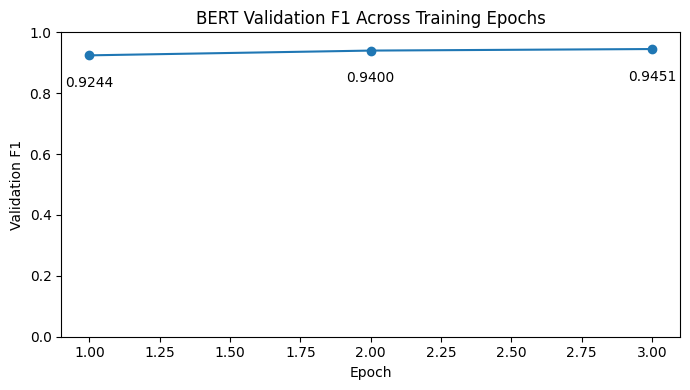

Figure saved to:
/kaggle/working/01_bert_baseline_and_uncertainty/figures/bert_validation_f1_by_epoch.png


In [33]:
plt.figure(
    figsize=(7, 4)
)

plt.plot(
    epoch_evaluation_df[
        "epoch"
    ],
    epoch_evaluation_df[
        "eval_f1"
    ],
    marker="o",
)


for epoch, f1 in zip(
    epoch_evaluation_df["epoch"],
    epoch_evaluation_df["eval_f1"],
):

    plt.annotate(
        f"{f1:.4f}",
        (epoch, f1),
        textcoords="offset points",
        xytext=(0, -15),
        ha="center",
        va="top",
    )


plt.title(
    "BERT Validation F1 Across Training Epochs"
)

plt.xlabel("Epoch")
plt.ylabel("Validation F1")
plt.ylim(0.0, 1.0)

plt.tight_layout()


validation_f1_figure_path = (
    FIGURE_OUTPUT_DIR
    / "bert_validation_f1_by_epoch.png"
)


plt.savefig(
    validation_f1_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Figure saved to:"
)

print(
    validation_f1_figure_path
)

### 10.2 Training and Validation Learning Curve

Training loss summarises optimisation on the fitting population, while validation loss describes model behaviour on the frozen validation population.

These curves provide context for the validation F1 trajectory but do not alter checkpoint selection.

In [34]:
# Retain logged training-loss entries.
training_loss_df = (
    training_history_df.loc[
        training_history_df[
            "loss"
        ].notna()
    ]
    .copy()
)


# Assign each logged training loss to
# its corresponding training epoch.
training_loss_df[
    "Training Epoch"
] = np.ceil(
    training_loss_df["epoch"]
).astype(int)


# Average logged training losses
# within each epoch.
epoch_training_loss_df = (
    training_loss_df
    .groupby(
        "Training Epoch",
        as_index=False,
    )
    .agg(
        Training_Loss=(
            "loss",
            "mean",
        )
    )
)


# Retain the validation loss
# recorded after each epoch.
epoch_validation_loss_df = (
    epoch_evaluation_df[
        [
            "epoch",
            "eval_loss",
        ]
    ]
    .copy()
)


epoch_validation_loss_df[
    "Validation Epoch"
] = (
    epoch_validation_loss_df[
        "epoch"
    ]
    .round()
    .astype(int)
)


# Combine training and validation
# losses into one table.
learning_curve_df = (
    epoch_training_loss_df
    .merge(
        epoch_validation_loss_df[
            [
                "Validation Epoch",
                "eval_loss",
            ]
        ],
        left_on="Training Epoch",
        right_on="Validation Epoch",
        how="inner",
    )
    .rename(
        columns={
            "Training Epoch": "Epoch",
            "Training_Loss": (
                "Training Loss"
            ),
            "eval_loss": (
                "Validation Loss"
            ),
        }
    )
    [
        [
            "Epoch",
            "Training Loss",
            "Validation Loss",
        ]
    ]
)


print(
    "Training and validation loss by epoch:"
)

display(
    learning_curve_df.round(4)
)

Training and validation loss by epoch:


,Epoch,Training Loss,Validation Loss
0,1,0.3254,0.0865
1,2,0.0693,0.0749
2,3,0.0404,0.0730


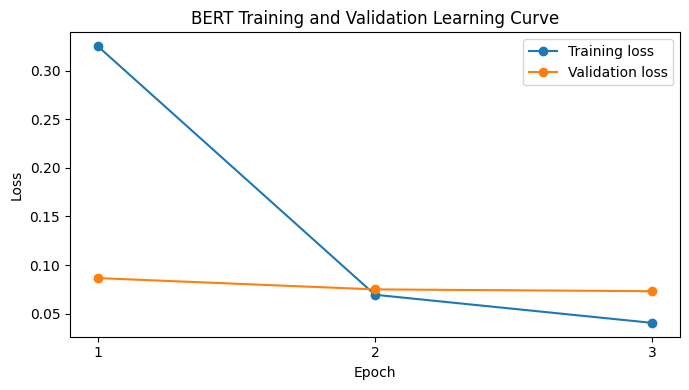

Figure saved to:
/kaggle/working/01_bert_baseline_and_uncertainty/figures/bert_training_validation_learning_curve.png


In [35]:
plt.figure(
    figsize=(7, 4)
)


plt.plot(
    learning_curve_df[
        "Epoch"
    ],
    learning_curve_df[
        "Training Loss"
    ],
    marker="o",
    label="Training loss",
)


plt.plot(
    learning_curve_df[
        "Epoch"
    ],
    learning_curve_df[
        "Validation Loss"
    ],
    marker="o",
    label="Validation loss",
)


plt.title(
    "BERT Training and Validation Learning Curve"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(
    learning_curve_df[
        "Epoch"
    ]
)

plt.legend()
plt.tight_layout()


learning_curve_figure_path = (
    FIGURE_OUTPUT_DIR
    / "bert_training_validation_learning_curve.png"
)


plt.savefig(
    learning_curve_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Figure saved to:"
)

print(
    learning_curve_figure_path
)

### 10.3 Selected Checkpoint

The selected checkpoint is determined entirely by the highest validation entity-level F1 recorded during training.

In [36]:
best_epoch_row = (
    epoch_evaluation_df.loc[
        epoch_evaluation_df[
            "eval_f1"
        ].idxmax()
    ]
)


best_epoch = float(
    best_epoch_row[
        "epoch"
    ]
)

best_epoch_f1 = float(
    best_epoch_row[
        "eval_f1"
    ]
)


training_diagnostic_summary = pd.DataFrame({
    "Measure": [
        "Selected epoch",
        "Validation F1 at selected epoch",
        "Validation loss at selected epoch",
    ],

    "Value": [
        best_epoch,
        best_epoch_f1,
        float(
            best_epoch_row[
                "eval_loss"
            ]
        ),
    ],
})


display(
    training_diagnostic_summary
)

,Measure,Value
0,Selected epoch,3.000000
1,Validation F1 at selected epoch,0.945124
2,Validation loss at selected epoch,0.073008


## 11. Save and Verify the Fine-Tuned BERT Checkpoint

The checkpoint selected by validation F1 is saved together with its tokenizer.

Because all subsequent deterministic and stochastic uncertainty analyses depend on this trained model, checkpoint integrity is verified immediately after saving.

The verification has three levels:

1. the saved checkpoint must reload without missing, unexpected or mismatched model parameters;
2. the reloaded model parameters must exactly match the trained in-memory parameters;
3. deterministic validation predictions from the reloaded checkpoint must reproduce those from the trained model.

Only after these checks pass is the reloaded checkpoint treated as the fixed BERT model for the remainder of the notebook.

In [37]:
# Save the checkpoint currently held by the Trainer.
trainer.save_model(
    MODEL_DIR
)

tokenizer.save_pretrained(
    MODEL_DIR
)


training_summary = {
    "model_checkpoint": (
        MODEL_CHECKPOINT
    ),

    "seed": SEED,

    "max_length": (
        MAX_LENGTH
    ),

    "training_configuration": (
        training_configuration
    ),

    "training_sentences": int(
        len(
            model_dataset[
                "train"
            ]
        )
    ),

    "validation_sentences": int(
        len(
            model_dataset[
                "validation"
            ]
        )
    ),

    "training_duration_minutes": float(
        training_duration_minutes
    ),

    "selected_checkpoint": (
        trainer.state
        .best_model_checkpoint
    ),

    "best_validation_f1": float(
        trainer.state.best_metric
    ),

    "selected_epoch": float(
        best_epoch
    ),

    "test_evaluated": False,
}


training_summary_path = (
    METRICS_OUTPUT_DIR
    / "training_summary.json"
)


with open(
    training_summary_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        training_summary,
        file,
        indent=2,
    )


print(
    "Fine-tuned model saved to:"
)

print(
    MODEL_DIR
)


print(
    "\nTraining summary saved to:"
)

print(
    training_summary_path
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model saved to:
/kaggle/working/01_bert_baseline_and_uncertainty/final_model

Training summary saved to:
/kaggle/working/01_bert_baseline_and_uncertainty/metrics/training_summary.json


### 11.2 Generate Reference Predictions from the Trained Model

A deterministic validation forward pass is generated from the trained in-memory model before reloading the saved checkpoint.

These outputs form the reference for the checkpoint-reproduction test.

Dropout is disabled because the model is evaluated in standard deterministic inference mode.

In [38]:
trainer.model.eval()


reference_validation_output = (
    trainer.predict(
        model_dataset[
            "validation"
        ]
    )
)


reference_validation_logits = (
    reference_validation_output
    .predictions
)


if isinstance(
    reference_validation_logits,
    tuple,
):
    reference_validation_logits = (
        reference_validation_logits[0]
    )


reference_validation_logits = (
    np.asarray(
        reference_validation_logits,
        dtype=np.float32,
    )
)


reference_validation_labels = (
    np.asarray(
        reference_validation_output
        .label_ids,
        dtype=np.int16,
    )
)


reference_validation_predictions = (
    np.argmax(
        reference_validation_logits,
        axis=-1,
    )
    .astype(np.int16)
)


print(
    "Reference validation logits:",
    reference_validation_logits.shape,
)

print(
    "Reference validation labels:",
    reference_validation_labels.shape,
)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Reference validation logits: (1625, 121, 9)
Reference validation labels: (1625, 121)


### 11.3 Reload the Saved Model Independently

The model and tokenizer are reloaded directly from the saved local checkpoint.

Loading diagnostics are inspected explicitly so that missing, unexpected or shape-mismatched model parameters cannot pass silently.

In [39]:
reloaded_tokenizer = (
    AutoTokenizer.from_pretrained(
        MODEL_DIR,
        use_fast=True,
        local_files_only=True,
    )
)


(
    reloaded_model,
    loading_info,
) = (
    AutoModelForTokenClassification
    .from_pretrained(
        MODEL_DIR,
        local_files_only=True,
        output_loading_info=True,
    )
)


missing_keys = list(
    loading_info.get(
        "missing_keys",
        [],
    )
)

unexpected_keys = list(
    loading_info.get(
        "unexpected_keys",
        [],
    )
)

mismatched_keys = list(
    loading_info.get(
        "mismatched_keys",
        [],
    )
)


loading_audit_df = pd.DataFrame({
    "Loading Check": [
        "Missing keys",
        "Unexpected keys",
        "Mismatched keys",
    ],

    "Count": [
        len(missing_keys),
        len(unexpected_keys),
        len(mismatched_keys),
    ],
})


print(
    "Checkpoint loading audit:"
)

display(
    loading_audit_df
)


if missing_keys:
    print(
        "Missing keys:",
        missing_keys,
    )

if unexpected_keys:
    print(
        "Unexpected keys:",
        unexpected_keys,
    )

if mismatched_keys:
    print(
        "Mismatched keys:",
        mismatched_keys,
    )


assert len(
    missing_keys
) == 0

assert len(
    unexpected_keys
) == 0

assert len(
    mismatched_keys
) == 0


assert (
    reloaded_tokenizer.is_fast
)


assert (
    reloaded_model.config.num_labels
    == len(label_names)
)


reloaded_id2label = {
    int(label_id): label
    for label_id, label
    in reloaded_model
    .config.id2label.items()
}


assert (
    reloaded_id2label
    == id2label
)


print(
    "Checkpoint reloaded without "
    "parameter-loading anomalies."
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Checkpoint loading audit:


,Loading Check,Count
0,Missing keys,0
1,Unexpected keys,0
2,Mismatched keys,0


Checkpoint reloaded without parameter-loading anomalies.


### 11.4 Verify Trained-Weight Equality

The state dictionary of the reloaded model is compared directly with the state dictionary of the trained model.

Every parameter name and tensor value must match exactly.

In [40]:
trained_state_dict = (
    trainer.model.state_dict()
)

reloaded_state_dict = (
    reloaded_model.state_dict()
)


trained_keys = set(
    trained_state_dict.keys()
)

reloaded_keys = set(
    reloaded_state_dict.keys()
)


assert (
    trained_keys
    == reloaded_keys
)


parameter_comparison_rows = []

all_parameters_identical = True


for parameter_name in sorted(
    trained_keys
):

    trained_tensor = (
        trained_state_dict[
            parameter_name
        ]
        .detach()
        .cpu()
    )

    reloaded_tensor = (
        reloaded_state_dict[
            parameter_name
        ]
        .detach()
        .cpu()
    )


    tensor_identical = torch.equal(
        trained_tensor,
        reloaded_tensor,
    )


    if not tensor_identical:
        all_parameters_identical = False


    parameter_comparison_rows.append({
        "Parameter": (
            parameter_name
        ),
        "Shape": tuple(
            trained_tensor.shape
        ),
        "Exact Match": (
            tensor_identical
        ),
    })


parameter_comparison_df = (
    pd.DataFrame(
        parameter_comparison_rows
    )
)


assert (
    all_parameters_identical
)


assert (
    parameter_comparison_df[
        "Exact Match"
    ].all()
)


print(
    "Model tensors checked:",
    len(
        parameter_comparison_df
    ),
)

print(
    "All saved/reloaded parameters "
    "match exactly:",
    all_parameters_identical,
)

Model tensors checked: 199
All saved/reloaded parameters match exactly: True


### 11.5 Create a Checkpoint Fingerprint

A SHA-256 fingerprint is computed over the ordered model state dictionary.

The fingerprint provides a compact identity for the trained BERT weights and can be checked by later notebooks that reload this checkpoint.

In [41]:
def model_state_sha256(model):
    """
    Compute a deterministic SHA-256 fingerprint
    over model parameter names, shapes, dtypes
    and tensor bytes.
    """

    digest = hashlib.sha256()


    for parameter_name, tensor in sorted(
        model.state_dict().items()
    ):

        tensor_cpu = (
            tensor
            .detach()
            .cpu()
            .contiguous()
        )


        digest.update(
            parameter_name.encode(
                "utf-8"
            )
        )

        digest.update(
            str(
                tuple(
                    tensor_cpu.shape
                )
            ).encode(
                "utf-8"
            )
        )

        digest.update(
            str(
                tensor_cpu.dtype
            ).encode(
                "utf-8"
            )
        )

        digest.update(
            tensor_cpu
            .numpy()
            .tobytes()
        )


    return digest.hexdigest()

In [42]:
trained_model_hash = (
    model_state_sha256(
        trainer.model
    )
)


reloaded_model_hash = (
    model_state_sha256(
        reloaded_model
    )
)


assert (
    trained_model_hash
    == reloaded_model_hash
)


print(
    "BERT checkpoint SHA-256:"
)

print(
    reloaded_model_hash
)

BERT checkpoint SHA-256:
556e22c5ac0118b96df59c427e3ac1252e9a6af72ac97b2b3d1cc04e0d5e89c8


### 11.6 Verify Deterministic Prediction Reproduction

The independently reloaded checkpoint is now evaluated on the same frozen validation population.

The reloaded model must reproduce:

- the same aligned gold labels;
- the same predicted BIO class at every evaluated BERT position;
- numerically equivalent logits.

This is the final gate before the checkpoint is used for span reconstruction or Monte Carlo Dropout.

In [45]:
# Prediction-only Trainer configuration

# The training Trainer used epoch-based evaluation.
# For checkpoint reproduction and downstream inference
# we only need deterministic prediction, so scheduled
# evaluation and checkpoint saving are disabled.

INFERENCE_RUNTIME_DIR = (
    OUTPUT_DIR / "inference_runtime"
)

INFERENCE_RUNTIME_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


inference_args = TrainingArguments(
    output_dir=str(
        INFERENCE_RUNTIME_DIR
    ),

    per_device_eval_batch_size=(
        training_configuration[
            "evaluation_batch_size"
        ]
    ),

    eval_strategy="no",
    save_strategy="no",

    seed=SEED,
    data_seed=SEED,

    report_to="none",
)


print(
    "Prediction-only Trainer "
    "configuration created."
)

Prediction-only Trainer configuration created.


In [46]:
reloaded_model = (
    reloaded_model.to(
        DEVICE
    )
)

reloaded_model.eval()


reloaded_prediction_trainer = Trainer(
    model=reloaded_model,
    args=inference_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=reloaded_tokenizer,
)


reloaded_validation_output = (
    reloaded_prediction_trainer.predict(
        model_dataset[
            "validation"
        ]
    )
)


reloaded_validation_logits = (
    reloaded_validation_output.predictions
)


if isinstance(
    reloaded_validation_logits,
    tuple,
):
    reloaded_validation_logits = (
        reloaded_validation_logits[0]
    )


reloaded_validation_logits = np.asarray(
    reloaded_validation_logits,
    dtype=np.float32,
)


reloaded_validation_labels = np.asarray(
    reloaded_validation_output.label_ids,
    dtype=np.int16,
)


reloaded_validation_predictions = (
    np.argmax(
        reloaded_validation_logits,
        axis=-1,
    )
    .astype(np.int16)
)

labels_identical = np.array_equal(
    reference_validation_labels,
    reloaded_validation_labels,
)


predictions_identical = (
    np.array_equal(
        reference_validation_predictions,
        reloaded_validation_predictions,
    )
)


maximum_logit_difference = float(
    np.max(
        np.abs(
            reference_validation_logits
            - reloaded_validation_logits
        )
    )
)


logits_numerically_equivalent = (
    np.allclose(
        reference_validation_logits,
        reloaded_validation_logits,
        rtol=1e-6,
        atol=1e-6,
    )
)


checkpoint_reproduction_df = pd.DataFrame({
    "Check": [
        "Gold label arrays identical",
        "Predicted BIO IDs identical",
        "Logits numerically equivalent",
        "Maximum absolute logit difference",
    ],

    "Result": [
        labels_identical,
        predictions_identical,
        logits_numerically_equivalent,
        maximum_logit_difference,
    ],
})


print(
    "Deterministic checkpoint "
    "reproduction audit:"
)

display(
    checkpoint_reproduction_df
)


assert labels_identical
assert predictions_identical
assert logits_numerically_equivalent


print(
    "Reloaded checkpoint reproduces "
    "the trained BERT predictions."
)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Deterministic checkpoint reproduction audit:


,Check,Result
0,Gold label arrays identical,True
1,Predicted BIO IDs identical,True
2,Logits numerically equivalent,True
3,Maximum absolute logit difference,0.0


Reloaded checkpoint reproduces the trained BERT predictions.


### 11.7 Freeze the Verified BERT Checkpoint

The independently reloaded checkpoint is now adopted as the canonical BERT model for all remaining deterministic and stochastic analyses.

No further parameter updates are permitted.

Monte Carlo Dropout later changes only dropout-module behaviour during repeated forward passes; it does not retrain or modify the model weights.

In [47]:
# The independently reloaded checkpoint becomes
# the canonical model used from this point onward.
model = reloaded_model
tokenizer = reloaded_tokenizer


for parameter in model.parameters():
    parameter.requires_grad_(
        False
    )


trainable_parameters = sum(
    parameter.numel()
    for parameter
    in model.parameters()
    if parameter.requires_grad
)


assert (
    trainable_parameters
    == 0
)


model.eval()


print(
    "Canonical BERT checkpoint frozen."
)

print(
    "Trainable parameters:",
    trainable_parameters,
)

print(
    "Model device:",
    next(
        model.parameters()
    ).device,
)

Canonical BERT checkpoint frozen.
Trainable parameters: 0
Model device: cuda:0


### Section 11.8 Save the Checkpoint-Integrity Record

In [48]:
checkpoint_integrity = {
    "checkpoint_directory": str(
        MODEL_DIR
    ),

    "model_sha256": (
        reloaded_model_hash
    ),

    "missing_keys": (
        missing_keys
    ),

    "unexpected_keys": (
        unexpected_keys
    ),

    "mismatched_keys": (
        mismatched_keys
    ),

    "exact_parameter_match": bool(
        all_parameters_identical
    ),

    "validation_labels_identical": bool(
        labels_identical
    ),

    "validation_predictions_identical": bool(
        predictions_identical
    ),

    "validation_logits_allclose": bool(
        logits_numerically_equivalent
    ),

    "maximum_absolute_logit_difference": (
        maximum_logit_difference
    ),

    "trainable_parameters_after_freeze": int(
        trainable_parameters
    ),
}


checkpoint_integrity_path = (
    CONFIG_OUTPUT_DIR
    / "bert_checkpoint_integrity.json"
)


with open(
    checkpoint_integrity_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        checkpoint_integrity,
        file,
        indent=2,
    )


print(
    "Checkpoint-integrity record saved to:"
)

print(
    checkpoint_integrity_path
)

Checkpoint-integrity record saved to:
/kaggle/working/01_bert_baseline_and_uncertainty/configuration/bert_checkpoint_integrity.json


### Section 11.9 Clean Up the Training Model

In [49]:
# The verified reloaded model is now the only
# model needed for downstream inference.

del reference_validation_output
del reloaded_validation_output

del reference_validation_logits
del reloaded_validation_logits

del reference_validation_predictions
del reloaded_validation_predictions

del reference_validation_labels
del reloaded_validation_labels


# The original Trainer still retains the
# pre-reload model and optimiser state.
del trainer


gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# Create one inference Trainer around the
# verified frozen checkpoint. This object
# will be reused for deterministic outputs.
prediction_trainer = Trainer(
    model=model,
    args=inference_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)


print(
    "Training resources released."
)

print(
    "Verified inference model retained."
)

Training resources released.
Verified inference model retained.


## 12. Generate Deterministic BERT Prediction Arrays

The verified and frozen BERT checkpoint is now used for deterministic inference on the three experimental development populations:

- validation;
- probability calibration;
- conformal calibration.

For each population, the notebook saves:

- raw nine-class logits;
- nine-class softmax probabilities;
- predicted BIO label IDs;
- aligned gold BIO label IDs.

These outputs provide the common deterministic model representation used by the later span-confidence, calibration and uncertainty analyses.

No model parameters are updated during this stage.

In [50]:
prediction_splits = [
    "validation",
    "probability_calibration",
    "conformal_calibration",
]


prediction_array_summary = []


model.eval()


for split_name in prediction_splits:

    print(
        f"Generating deterministic BERT outputs "
        f"for {split_name}..."
    )


    prediction_output = (
        prediction_trainer.predict(
            model_dataset[
                split_name
            ]
        )
    )


    logits = (
        prediction_output.predictions
    )


    if isinstance(
        logits,
        tuple,
    ):
        logits = logits[0]


    logits = np.asarray(
        logits,
        dtype=np.float32,
    )


    label_ids = np.asarray(
        prediction_output.label_ids,
        dtype=np.int16,
    )


    # Numerically stable softmax.
    shifted_logits = (
        logits
        - np.max(
            logits,
            axis=-1,
            keepdims=True,
        )
    )


    exp_logits = np.exp(
        shifted_logits
    )


    probabilities = (
        exp_logits
        / exp_logits.sum(
            axis=-1,
            keepdims=True,
        )
    ).astype(
        np.float32
    )


    predicted_ids = (
        np.argmax(
            probabilities,
            axis=-1,
        )
        .astype(
            np.int16
        )
    )


    # -----------------------------------------------------
    # Output integrity checks.
    # -----------------------------------------------------

    assert logits.ndim == 3

    assert (
        logits.shape[-1]
        == len(label_names)
    )

    assert (
        probabilities.shape
        == logits.shape
    )

    assert (
        label_ids.shape
        == logits.shape[:2]
    )

    assert np.allclose(
        probabilities.sum(
            axis=-1
        ),
        1.0,
        atol=1e-5,
    )


    prediction_array_path = (
        PREDICTION_ARRAY_DIR
        / (
            f"{split_name}_"
            "prediction_arrays.npz"
        )
    )


    np.savez_compressed(
        prediction_array_path,
        logits=logits,
        probabilities=probabilities,
        predicted_ids=predicted_ids,
        label_ids=label_ids,
    )


    prediction_array_summary.append({
        "Split": split_name,
        "Sentences": int(
            logits.shape[0]
        ),
        "Padded BERT Positions": int(
            logits.shape[1]
        ),
        "BIO Classes": int(
            logits.shape[2]
        ),
    })


    del prediction_output
    del logits
    del probabilities
    del predicted_ids
    del label_ids


prediction_array_summary_df = (
    pd.DataFrame(
        prediction_array_summary
    )
)


print(
    "Saved deterministic BERT arrays:"
)

display(
    prediction_array_summary_df
)

Generating deterministic BERT outputs for validation...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Generating deterministic BERT outputs for probability_calibration...


Generating deterministic BERT outputs for conformal_calibration...


Saved deterministic BERT arrays:


,Split,Sentences,Padded BERT Positions,BIO Classes
0,validation,1625,121,9
1,probability_calibration,975,139,9
2,conformal_calibration,650,151,9


## 13. Reconstruct Original-Word Predictions

The saved model arrays operate at BERT-subword level.

For downstream NER analysis, predictions are mapped back to the original CoNLL-2003 words by retaining only the first subword position associated with each original word.

Each original-word record retains:

- gold BIO label;
- predicted BIO label;
- the complete nine-class probability distribution;
- maximum predicted probability;
- predictive entropy of the deterministic softmax distribution;
- probability margin between the two most probable BIO classes.

These are raw, uncalibrated model outputs.

In [51]:
probability_column_names = [
    "prob_"
    + label.replace(
        "-",
        "_",
    )
    for label in label_names
]


assert (
    len(
        probability_column_names
    )
    == len(label_names)
)


PROBABILITY_COLUMNS = list(
    probability_column_names
)


print(
    "Probability columns:"
)

print(
    PROBABILITY_COLUMNS
)



Probability columns:
['prob_O', 'prob_B_PER', 'prob_I_PER', 'prob_B_ORG', 'prob_I_ORG', 'prob_B_LOC', 'prob_I_LOC', 'prob_B_MISC', 'prob_I_MISC']


### Section 13.2 Build Original-Word Prediction Tables

In [52]:
token_prediction_tables = {}


for split_name in prediction_splits:

    prediction_array_path = (
        PREDICTION_ARRAY_DIR
        / (
            f"{split_name}_"
            "prediction_arrays.npz"
        )
    )


    with np.load(
        prediction_array_path
    ) as arrays:

        probabilities = (
            arrays[
                "probabilities"
            ]
        )

        predicted_ids = (
            arrays[
                "predicted_ids"
            ]
        )

        label_ids = (
            arrays[
                "label_ids"
            ]
        )


    token_records = []


    for sentence_index, example in enumerate(
        tokenized_dataset[
            split_name
        ]
    ):

        first_subword_positions = [
            position
            for position, indicator
            in enumerate(
                example[
                    "first_subword_mask"
                ]
            )
            if indicator == 1
        ]


        assert (
            len(
                first_subword_positions
            )
            == len(
                example["tokens"]
            )
        )


        for bert_position in (
            first_subword_positions
        ):

            token_index = int(
                example[
                    "word_ids"
                ][
                    bert_position
                ]
            )


            probability_vector = (
                probabilities[
                    sentence_index,
                    bert_position,
                ]
            )


            gold_label_id = int(
                label_ids[
                    sentence_index,
                    bert_position,
                ]
            )


            predicted_label_id = int(
                predicted_ids[
                    sentence_index,
                    bert_position,
                ]
            )


            # Every retained first-subword position
            # must correspond to an evaluated BIO label.
            assert (
                gold_label_id
                != -100
            )


            maximum_probability = float(
                probability_vector[
                    predicted_label_id
                ]
            )


            safe_probabilities = np.clip(
                probability_vector,
                1e-12,
                1.0,
            )


            entropy = float(
                -np.sum(
                    safe_probabilities
                    * np.log(
                        safe_probabilities
                    )
                )
            )


            sorted_probabilities = (
                np.sort(
                    probability_vector
                )
            )


            probability_margin = float(
                sorted_probabilities[-1]
                - sorted_probabilities[-2]
            )


            token_record = {
                "split": split_name,

                "source_index": int(
                    example[
                        "source_index"
                    ]
                ),

                "sentence_id": str(
                    example["id"]
                ),

                "sentence_index": int(
                    sentence_index
                ),

                "sentence_length": int(
                    len(
                        example["tokens"]
                    )
                ),

                "token_index": (
                    token_index
                ),

                "bert_position": int(
                    bert_position
                ),

                "token": (
                    example[
                        "tokens"
                    ][
                        token_index
                    ]
                ),

                "gold_label_id": (
                    gold_label_id
                ),

                "gold_bio_label": (
                    id2label[
                        gold_label_id
                    ]
                ),

                "predicted_label_id": (
                    predicted_label_id
                ),

                "predicted_bio_label": (
                    id2label[
                        predicted_label_id
                    ]
                ),

                "is_token_correct": (
                    predicted_label_id
                    == gold_label_id
                ),

                "token_max_probability_proxy": (
                    maximum_probability
                ),

                "token_entropy_proxy": (
                    entropy
                ),

                "token_margin_proxy": (
                    probability_margin
                ),
            }


            for (
                column_name,
                probability,
            ) in zip(
                probability_column_names,
                probability_vector,
            ):

                token_record[
                    column_name
                ] = float(
                    probability
                )


            token_records.append(
                token_record
            )


    split_token_df = pd.DataFrame(
        token_records
    )


    # Identity/order checks.

    saved_identity = (
        split_information[
            "identities"
        ][
            split_name
        ]
    )


    assert (
        len(
            split_token_df
        )
        == saved_identity[
            "tokens"
        ]
    )


    expected_source_order = [
        int(index)
        for index
        in split_information[
            "splits"
        ][
            split_name
        ]
    ]


    reconstructed_source_order = (
        split_token_df[
            [
                "sentence_index",
                "source_index",
            ]
        ]
        .drop_duplicates()
        .sort_values(
            "sentence_index"
        )[
            "source_index"
        ]
        .astype(int)
        .tolist()
    )


    assert (
        reconstructed_source_order
        == expected_source_order
    )


    token_prediction_tables[
        split_name
    ] = split_token_df


    token_table_path = (
        TOKEN_OUTPUT_DIR
        / (
            f"{split_name}_"
            "token_predictions.csv"
        )
    )


    split_token_df.to_csv(
        token_table_path,
        index=False,
    )


    print(
        f"{split_name}: "
        f"{len(split_token_df):,} "
        "original-word predictions saved."
    )

validation: 26,021 original-word predictions saved.
probability_calibration: 15,726 original-word predictions saved.
conformal_calibration: 9,615 original-word predictions saved.


### Section 13.3 Prediction Summary

In [53]:
token_prediction_summary_df = (
    pd.DataFrame({
        "Split": (
            prediction_splits
        ),

        "Original-Word Predictions": [
            len(
                token_prediction_tables[
                    split_name
                ]
            )
            for split_name
            in prediction_splits
        ],

        "Token Accuracy": [
            float(
                token_prediction_tables[
                    split_name
                ][
                    "is_token_correct"
                ].mean()
            )
            for split_name
            in prediction_splits
        ],
    })
)


print(
    "Original-word prediction summary:"
)

display(
    token_prediction_summary_df.round(
        4
    )
)

Original-word prediction summary:


,Split,Original-Word Predictions,Token Accuracy
0,validation,26021,0.9909
1,probability_calibration,15726,0.9891
2,conformal_calibration,9615,0.9913


## 14. Reconstruct and Evaluate Entity Spans

BERT produces BIO labels at the word level, whereas the dissertation focuses on complete entity spans and their start and end boundaries.

Gold and predicted BIO sequences are therefore converted into typed entity spans.

Malformed predicted BIO sequences are repaired deterministically: an isolated `I-X`, or an `I-X` following an incompatible entity type, begins a new entity of type `X`.

For predicted spans, several deterministic confidence summaries are retained. These include a geometric mean of the token-level probabilities assigned to the emitted BIO labels. This geometric aggregation is a project-specific span-confidence construction used consistently throughout the BERT experiments; it is not treated as a field-standard span-calibration method.

Predicted and gold spans are then matched one-to-one within each sentence for diagnostic error analysis. Strict NER correctness still requires an exact match of start boundary, end boundary and entity type.

In [54]:
def bio_to_spans(
    tokens,
    tags,
):
    """
    Convert one BIO sequence into typed entity spans.

    Malformed I-X labels are repaired by treating them
    as the beginning of a new entity of type X.
    """

    if len(tokens) != len(tags):
        raise ValueError(
            "Token and BIO-label counts "
            "must be identical."
        )


    spans = []
    current_entity = None


    def close_current_entity(
        entity,
        end_index,
    ):

        entity["end"] = int(
            end_index
        )

        entity["text"] = " ".join(
            tokens[
                entity["start"]:
                end_index + 1
            ]
        )

        spans.append(
            entity
        )


    for token_index, tag in enumerate(
        tags
    ):

        if tag == "O":

            if current_entity is not None:

                close_current_entity(
                    current_entity,
                    token_index - 1,
                )

                current_entity = None


        elif (
            tag.startswith(
                "B-"
            )
            and len(tag) > 2
        ):

            if current_entity is not None:

                close_current_entity(
                    current_entity,
                    token_index - 1,
                )


            current_entity = {
                "type": tag[2:],
                "start": int(
                    token_index
                ),
                "end": int(
                    token_index
                ),
            }


        elif (
            tag.startswith(
                "I-"
            )
            and len(tag) > 2
        ):

            entity_type = tag[2:]


            if (
                current_entity
                is not None
                and current_entity[
                    "type"
                ]
                == entity_type
            ):

                current_entity[
                    "end"
                ] = int(
                    token_index
                )


            else:

                # Deterministic BIO repair.
                if current_entity is not None:

                    close_current_entity(
                        current_entity,
                        token_index - 1,
                    )


                current_entity = {
                    "type": (
                        entity_type
                    ),
                    "start": int(
                        token_index
                    ),
                    "end": int(
                        token_index
                    ),
                }


        else:

            raise ValueError(
                "Unexpected BIO label: "
                f"{tag}"
            )


    if current_entity is not None:

        close_current_entity(
            current_entity,
            len(tokens) - 1,
        )


    return spans

### 14.2 Reconstruct Gold Entity Spans

Gold BIO annotations are reconstructed independently for each experimental population.

The resulting gold-span counts are verified against the identities produced by Notebook 00 rather than against hard-coded results from an earlier execution.

In [55]:
gold_span_tables = {}


for split_name in prediction_splits:

    gold_span_records = []


    for sentence_index, example in enumerate(
        dataset_splits[
            split_name
        ]
    ):

        tokens = list(
            example["tokens"]
        )


        gold_tags = [
            id2label[
                int(tag_id)
            ]
            for tag_id
            in example[
                "ner_tags"
            ]
        ]


        sentence_gold_spans = (
            bio_to_spans(
                tokens=tokens,
                tags=gold_tags,
            )
        )


        for span in sentence_gold_spans:

            gold_span_records.append({
                "split": split_name,

                "source_index": int(
                    example[
                        "source_index"
                    ]
                ),

                "sentence_id": str(
                    example["id"]
                ),

                "sentence_index": int(
                    sentence_index
                ),

                "entity_text": (
                    span["text"]
                ),

                "entity_type": (
                    span["type"]
                ),

                "start": int(
                    span["start"]
                ),

                "end": int(
                    span["end"]
                ),

                "token_count": int(
                    span["end"]
                    - span["start"]
                    + 1
                ),

                "sentence_length": (
                    len(tokens)
                ),
            })


    gold_spans_df = pd.DataFrame(
        gold_span_records
    )


    expected_gold_spans = int(
        split_information[
            "identities"
        ][
            split_name
        ][
            "gold_spans"
        ]
    )


    assert (
        len(
            gold_spans_df
        )
        == expected_gold_spans
    )


    gold_span_tables[
        split_name
    ] = gold_spans_df


    gold_spans_df.to_csv(
        SPAN_OUTPUT_DIR
        / (
            f"{split_name}_"
            "gold_spans.csv"
        ),
        index=False,
    )


gold_entity_spans_df = pd.concat(
    [
        gold_span_tables[
            split_name
        ]
        for split_name
        in prediction_splits
    ],
    ignore_index=True,
)


gold_entity_spans_df.to_csv(
    SPAN_OUTPUT_DIR
    / "gold_entity_spans.csv",
    index=False,
)


gold_span_summary_df = pd.DataFrame({
    "Split": prediction_splits,

    "Gold Entity Spans": [
        len(
            gold_span_tables[
                split_name
            ]
        )
        for split_name
        in prediction_splits
    ],
})


print(
    "Gold entity-span counts:"
)

display(
    gold_span_summary_df
)

Gold entity-span counts:


,Split,Gold Entity Spans
0,validation,3011
1,probability_calibration,1756
2,conformal_calibration,1175


### Section 14.3 Define Geometric Span Confidence

In [56]:
def geometric_mean(
    values,
    epsilon=1e-12,
):
    """
    Calculate a numerically stable geometric mean.
    """

    values = np.asarray(
        values,
        dtype=float,
    )


    return float(
        np.exp(
            np.mean(
                np.log(
                    np.clip(
                        values,
                        epsilon,
                        1.0,
                    )
                )
            )
        )
    )

### Section 14.4 Build Predicted Span Tables

In [57]:
predicted_span_tables = {}


for split_name in prediction_splits:

    token_df = (
        token_prediction_tables[
            split_name
        ]
    )

    predicted_span_records = []


    for sentence_index, example in enumerate(
        dataset_splits[
            split_name
        ]
    ):

        original_tokens = list(
            example["tokens"]
        )


        sentence_token_df = (
            token_df.loc[
                token_df[
                    "sentence_index"
                ].eq(
                    sentence_index
                )
            ]
            .sort_values(
                "token_index"
            )
            .reset_index(
                drop=True
            )
        )


        assert (
            len(
                sentence_token_df
            )
            == len(
                original_tokens
            )
        )


        predicted_tags = (
            sentence_token_df[
                "predicted_bio_label"
            ].tolist()
        )


        sentence_predicted_spans = (
            bio_to_spans(
                tokens=(
                    original_tokens
                ),
                tags=(
                    predicted_tags
                ),
            )
        )


        for span in (
            sentence_predicted_spans
        ):

            start_index = int(
                span["start"]
            )

            end_index = int(
                span["end"]
            )


            span_token_rows = (
                sentence_token_df.loc[
                    sentence_token_df[
                        "token_index"
                    ].between(
                        start_index,
                        end_index,
                    )
                ]
                .sort_values(
                    "token_index"
                )
            )


            confidence_values = (
                span_token_rows[
                    "token_max_probability_proxy"
                ].to_numpy(
                    dtype=float
                )
            )


            entropy_values = (
                span_token_rows[
                    "token_entropy_proxy"
                ].to_numpy(
                    dtype=float
                )
            )


            margin_values = (
                span_token_rows[
                    "token_margin_proxy"
                ].to_numpy(
                    dtype=float
                )
            )


            predicted_span_records.append({
                "split": split_name,

                "source_index": int(
                    example[
                        "source_index"
                    ]
                ),

                "sentence_id": str(
                    example["id"]
                ),

                "sentence_index": int(
                    sentence_index
                ),

                "sentence_length": int(
                    len(
                        original_tokens
                    )
                ),

                "entity_text": (
                    span["text"]
                ),

                "entity_type": (
                    span["type"]
                ),

                "start": (
                    start_index
                ),

                "end": (
                    end_index
                ),

                "token_count": int(
                    end_index
                    - start_index
                    + 1
                ),

                "start_token_confidence_proxy": float(
                    confidence_values[0]
                ),

                "end_token_confidence_proxy": float(
                    confidence_values[-1]
                ),

                "span_min_confidence_proxy": float(
                    confidence_values.min()
                ),

                "span_mean_confidence_proxy": float(
                    confidence_values.mean()
                ),

                "span_geometric_confidence_proxy": (
                    geometric_mean(
                        confidence_values
                    )
                ),

                "span_mean_entropy_proxy": float(
                    entropy_values.mean()
                ),

                "span_max_entropy_proxy": float(
                    entropy_values.max()
                ),

                "span_min_margin_proxy": float(
                    margin_values.min()
                ),

                "span_mean_margin_proxy": float(
                    margin_values.mean()
                ),
            })


    predicted_spans_df = (
        pd.DataFrame(
            predicted_span_records
        )
    )


    predicted_span_tables[
        split_name
    ] = predicted_spans_df


    predicted_spans_df.to_csv(
        SPAN_OUTPUT_DIR
        / (
            f"{split_name}_"
            "predicted_spans.csv"
        ),
        index=False,
    )


predicted_span_summary_df = pd.DataFrame({
    "Split": prediction_splits,

    "Predicted Entity Spans": [
        len(
            predicted_span_tables[
                split_name
            ]
        )
        for split_name
        in prediction_splits
    ],
})


span_count_summary_df = (
    gold_span_summary_df.merge(
        predicted_span_summary_df,
        on="Split",
        how="inner",
    )
)


print(
    "Gold and predicted entity-span counts:"
)

display(
    span_count_summary_df
)

Gold and predicted entity-span counts:


,Split,Gold Entity Spans,Predicted Entity Spans
0,validation,3011,3039
1,probability_calibration,1756,1771
2,conformal_calibration,1175,1182


### 14.5 Construct the Diagnostic Span-Matching Representation

Predicted and gold entities are matched one-to-one within each sentence.

The matching procedure prioritises:

1. exact boundaries and entity type;
2. exact boundaries with a different entity type;
3. remaining overlapping spans, prioritising type agreement, overlap size, IoU and boundary distance.

Unmatched predictions are labelled `false_positive`, while unmatched gold entities are labelled `false_negative`.

This matching table is a diagnostic representation used to distinguish type and boundary-error patterns. Primary strict NER correctness continues to require exact typed-span equality.

In [58]:
prediction_proxy_columns = [
    "start_token_confidence_proxy",
    "end_token_confidence_proxy",
    "span_min_confidence_proxy",
    "span_mean_confidence_proxy",
    "span_geometric_confidence_proxy",
    "span_mean_entropy_proxy",
    "span_max_entropy_proxy",
    "span_min_margin_proxy",
    "span_mean_margin_proxy",
]


def calculate_overlap_features(
    predicted_span,
    gold_span,
):

    predicted_start = int(
        predicted_span["start"]
    )

    predicted_end = int(
        predicted_span["end"]
    )

    gold_start = int(
        gold_span["start"]
    )

    gold_end = int(
        gold_span["end"]
    )


    overlap_tokens = max(
        0,
        min(
            predicted_end,
            gold_end,
        )
        - max(
            predicted_start,
            gold_start,
        )
        + 1,
    )


    predicted_length = (
        predicted_end
        - predicted_start
        + 1
    )

    gold_length = (
        gold_end
        - gold_start
        + 1
    )


    union_tokens = (
        predicted_length
        + gold_length
        - overlap_tokens
    )


    overlap_iou = (
        overlap_tokens
        / union_tokens
        if union_tokens > 0
        else 0.0
    )


    boundary_distance = (
        abs(
            predicted_start
            - gold_start
        )
        + abs(
            predicted_end
            - gold_end
        )
    )


    if (
        predicted_start
        == gold_start
        and predicted_end
        == gold_end
    ):
        relation = "exact"

    elif (
        predicted_start
        >= gold_start
        and predicted_end
        <= gold_end
        and overlap_tokens > 0
    ):
        relation = (
            "prediction_inside_gold"
        )

    elif (
        gold_start
        >= predicted_start
        and gold_end
        <= predicted_end
        and overlap_tokens > 0
    ):
        relation = (
            "gold_inside_prediction"
        )

    elif (
        predicted_start
        < gold_start
        <= predicted_end
        < gold_end
    ):
        relation = (
            "left_partial_overlap"
        )

    elif (
        gold_start
        < predicted_start
        <= gold_end
        < predicted_end
    ):
        relation = (
            "right_partial_overlap"
        )

    else:
        relation = "none"


    return {
        "overlap_tokens": int(
            overlap_tokens
        ),
        "overlap_iou": float(
            overlap_iou
        ),
        "boundary_distance": int(
            boundary_distance
        ),
        "overlap_relation": (
            relation
        ),
    }


def determine_matched_error_category(
    predicted_span,
    gold_span,
):

    start_match = (
        int(
            predicted_span["start"]
        )
        == int(
            gold_span["start"]
        )
    )

    end_match = (
        int(
            predicted_span["end"]
        )
        == int(
            gold_span["end"]
        )
    )

    type_match = (
        predicted_span[
            "entity_type"
        ]
        == gold_span[
            "entity_type"
        ]
    )


    if (
        start_match
        and end_match
        and type_match
    ):
        return "exact_match"

    if (
        start_match
        and end_match
    ):
        return "type_error"

    if (
        not start_match
        and end_match
    ):
        return (
            "start_boundary_error"
        )

    if (
        start_match
        and not end_match
    ):
        return (
            "end_boundary_error"
        )

    return "both_boundary_error"

In [59]:
def match_sentence_spans(
    predicted_spans,
    gold_spans,
    split_name,
    source_index,
    sentence_id,
    sentence_index,
):

    predicted_spans = [
        dict(span)
        for span
        in predicted_spans
    ]

    gold_spans = [
        dict(span)
        for span
        in gold_spans
    ]


    unmatched_predictions = set(
        range(
            len(
                predicted_spans
            )
        )
    )

    unmatched_gold = set(
        range(
            len(
                gold_spans
            )
        )
    )

    matched_pairs = []


    # Stage 1: exact typed-span matches.

    for prediction_index in sorted(
        unmatched_predictions.copy()
    ):

        prediction = (
            predicted_spans[
                prediction_index
            ]
        )


        candidates = [
            gold_index
            for gold_index
            in sorted(
                unmatched_gold
            )
            if (
                prediction["start"]
                == gold_spans[
                    gold_index
                ]["start"]
                and prediction["end"]
                == gold_spans[
                    gold_index
                ]["end"]
                and prediction[
                    "entity_type"
                ]
                == gold_spans[
                    gold_index
                ][
                    "entity_type"
                ]
            )
        ]


        if candidates:

            gold_index = (
                candidates[0]
            )

            matched_pairs.append(
                (
                    prediction_index,
                    gold_index,
                )
            )

            unmatched_predictions.remove(
                prediction_index
            )

            unmatched_gold.remove(
                gold_index
            )


    # Stage 2: exact boundaries, type mismatch.

    for prediction_index in sorted(
        unmatched_predictions.copy()
    ):

        prediction = (
            predicted_spans[
                prediction_index
            ]
        )


        candidates = [
            gold_index
            for gold_index
            in sorted(
                unmatched_gold
            )
            if (
                prediction["start"]
                == gold_spans[
                    gold_index
                ]["start"]
                and prediction["end"]
                == gold_spans[
                    gold_index
                ]["end"]
            )
        ]


        if candidates:

            gold_index = (
                candidates[0]
            )

            matched_pairs.append(
                (
                    prediction_index,
                    gold_index,
                )
            )

            unmatched_predictions.remove(
                prediction_index
            )

            unmatched_gold.remove(
                gold_index
            )


    # Stage 3: remaining overlapping spans.

    overlap_candidates = []


    for prediction_index in (
        unmatched_predictions
    ):

        prediction = (
            predicted_spans[
                prediction_index
            ]
        )


        for gold_index in (
            unmatched_gold
        ):

            gold = (
                gold_spans[
                    gold_index
                ]
            )


            features = (
                calculate_overlap_features(
                    prediction,
                    gold,
                )
            )


            if (
                features[
                    "overlap_tokens"
                ]
                == 0
            ):
                continue


            overlap_candidates.append({
                "prediction_index": (
                    prediction_index
                ),

                "gold_index": (
                    gold_index
                ),

                "type_match": (
                    prediction[
                        "entity_type"
                    ]
                    == gold[
                        "entity_type"
                    ]
                ),

                **features,
            })


    overlap_candidates.sort(
        key=lambda row: (
            -int(
                row[
                    "type_match"
                ]
            ),
            -row[
                "overlap_tokens"
            ],
            -row[
                "overlap_iou"
            ],
            row[
                "boundary_distance"
            ],
            row[
                "prediction_index"
            ],
            row[
                "gold_index"
            ],
        )
    )


    for candidate in (
        overlap_candidates
    ):

        prediction_index = (
            candidate[
                "prediction_index"
            ]
        )

        gold_index = (
            candidate[
                "gold_index"
            ]
        )


        if (
            prediction_index
            not in
            unmatched_predictions
            or gold_index
            not in
            unmatched_gold
        ):
            continue


        matched_pairs.append(
            (
                prediction_index,
                gold_index,
            )
        )

        unmatched_predictions.remove(
            prediction_index
        )

        unmatched_gold.remove(
            gold_index
        )


    rows = []


    # Matched pairs.

    for (
        prediction_index,
        gold_index,
    ) in matched_pairs:

        prediction = (
            predicted_spans[
                prediction_index
            ]
        )

        gold = (
            gold_spans[
                gold_index
            ]
        )


        overlap = (
            calculate_overlap_features(
                prediction,
                gold,
            )
        )


        start_match = (
            int(
                prediction[
                    "start"
                ]
            )
            == int(
                gold["start"]
            )
        )

        end_match = (
            int(
                prediction[
                    "end"
                ]
            )
            == int(
                gold["end"]
            )
        )

        type_match = (
            prediction[
                "entity_type"
            ]
            == gold[
                "entity_type"
            ]
        )


        row = {
            "split": split_name,
            "source_index": (
                source_index
            ),
            "sentence_id": (
                sentence_id
            ),
            "sentence_index": (
                sentence_index
            ),

            "row_source": (
                "matched_pair"
            ),

            "error_category": (
                determine_matched_error_category(
                    prediction,
                    gold,
                )
            ),

            "predicted_entity_text": (
                prediction[
                    "entity_text"
                ]
            ),

            "predicted_entity_type": (
                prediction[
                    "entity_type"
                ]
            ),

            "predicted_start": int(
                prediction["start"]
            ),

            "predicted_end": int(
                prediction["end"]
            ),

            "gold_entity_text": (
                gold["entity_text"]
            ),

            "gold_entity_type": (
                gold["entity_type"]
            ),

            "gold_start": int(
                gold["start"]
            ),

            "gold_end": int(
                gold["end"]
            ),

            "start_offset": int(
                prediction["start"]
                - gold["start"]
            ),

            "end_offset": int(
                prediction["end"]
                - gold["end"]
            ),

            **overlap,

            "is_start_correct": bool(
                start_match
            ),

            "is_end_correct": bool(
                end_match
            ),

            "is_type_correct": bool(
                type_match
            ),

            "is_boundary_correct": bool(
                start_match
                and end_match
            ),

            "is_exact_correct": bool(
                start_match
                and end_match
                and type_match
            ),
        }


        for column in (
            prediction_proxy_columns
        ):
            row[column] = (
                prediction.get(
                    column
                )
            )


        rows.append(
            row
        )


    # Unmatched predictions.

    for prediction_index in sorted(
        unmatched_predictions
    ):

        prediction = (
            predicted_spans[
                prediction_index
            ]
        )


        row = {
            "split": split_name,
            "source_index": (
                source_index
            ),
            "sentence_id": (
                sentence_id
            ),
            "sentence_index": (
                sentence_index
            ),

            "row_source": (
                "unmatched_prediction"
            ),

            "error_category": (
                "false_positive"
            ),

            "predicted_entity_text": (
                prediction[
                    "entity_text"
                ]
            ),

            "predicted_entity_type": (
                prediction[
                    "entity_type"
                ]
            ),

            "predicted_start": int(
                prediction["start"]
            ),

            "predicted_end": int(
                prediction["end"]
            ),

            "gold_entity_text": None,
            "gold_entity_type": None,
            "gold_start": None,
            "gold_end": None,
            "start_offset": None,
            "end_offset": None,
            "overlap_tokens": 0,
            "overlap_iou": 0.0,
            "boundary_distance": None,
            "overlap_relation": "none",
            "is_start_correct": None,
            "is_end_correct": None,
            "is_type_correct": None,
            "is_boundary_correct": None,
            "is_exact_correct": False,
        }


        for column in (
            prediction_proxy_columns
        ):
            row[column] = (
                prediction.get(
                    column
                )
            )


        rows.append(
            row
        )


    # Unmatched gold spans.

    for gold_index in sorted(
        unmatched_gold
    ):

        gold = (
            gold_spans[
                gold_index
            ]
        )


        row = {
            "split": split_name,
            "source_index": (
                source_index
            ),
            "sentence_id": (
                sentence_id
            ),
            "sentence_index": (
                sentence_index
            ),

            "row_source": (
                "unmatched_gold"
            ),

            "error_category": (
                "false_negative"
            ),

            "predicted_entity_text": None,
            "predicted_entity_type": None,
            "predicted_start": None,
            "predicted_end": None,

            "gold_entity_text": (
                gold["entity_text"]
            ),

            "gold_entity_type": (
                gold["entity_type"]
            ),

            "gold_start": int(
                gold["start"]
            ),

            "gold_end": int(
                gold["end"]
            ),

            "start_offset": None,
            "end_offset": None,
            "overlap_tokens": 0,
            "overlap_iou": 0.0,
            "boundary_distance": None,
            "overlap_relation": "none",
            "is_start_correct": None,
            "is_end_correct": None,
            "is_type_correct": None,
            "is_boundary_correct": None,
            "is_exact_correct": False,
        }


        for column in (
            prediction_proxy_columns
        ):
            row[column] = None


        rows.append(
            row
        )


    return rows

### Section 14.6 Build and Save Matching Tables

In [60]:
matching_tables = {}


for split_name in prediction_splits:

    predicted_df = (
        predicted_span_tables[
            split_name
        ]
    )

    gold_df = (
        gold_span_tables[
            split_name
        ]
    )


    matching_rows = []


    for sentence_index, example in enumerate(
        dataset_splits[
            split_name
        ]
    ):

        sentence_predictions = (
            predicted_df.loc[
                predicted_df[
                    "sentence_index"
                ].eq(
                    sentence_index
                )
            ]
            .sort_values(
                [
                    "start",
                    "end",
                    "entity_type",
                ]
            )
            .to_dict(
                orient="records"
            )
        )


        sentence_gold = (
            gold_df.loc[
                gold_df[
                    "sentence_index"
                ].eq(
                    sentence_index
                )
            ]
            .sort_values(
                [
                    "start",
                    "end",
                    "entity_type",
                ]
            )
            .to_dict(
                orient="records"
            )
        )


        matching_rows.extend(
            match_sentence_spans(
                predicted_spans=(
                    sentence_predictions
                ),
                gold_spans=(
                    sentence_gold
                ),
                split_name=(
                    split_name
                ),
                source_index=int(
                    example[
                        "source_index"
                    ]
                ),
                sentence_id=str(
                    example["id"]
                ),
                sentence_index=int(
                    sentence_index
                ),
            )
        )


    split_matching_df = (
        pd.DataFrame(
            matching_rows
        )
    )


    split_matching_df[
        "match_id"
    ] = (
        split_matching_df[
            "split"
        ].astype(str)
        + "_"
        + split_matching_df[
            "source_index"
        ].astype(str)
        + "_"
        + (
            split_matching_df
            .groupby(
                "source_index"
            )
            .cumcount()
            + 1
        ).astype(str)
    )


    split_matching_df[
        "is_any_error"
    ] = (
        ~split_matching_df[
            "is_exact_correct"
        ].astype(bool)
    )


    assert (
        split_matching_df[
            "predicted_start"
        ].notna().sum()
        == len(
            predicted_df
        )
    )


    assert (
        split_matching_df[
            "gold_start"
        ].notna().sum()
        == len(
            gold_df
        )
    )


    matching_tables[
        split_name
    ] = split_matching_df


    split_matching_df.to_csv(
        MATCHING_OUTPUT_DIR
        / (
            f"{split_name}_"
            "span_matching.csv"
        ),
        index=False,
    )


master_span_matching_df = (
    pd.concat(
        [
            matching_tables[
                split_name
            ]
            for split_name
            in prediction_splits
        ],
        ignore_index=True,
    )
)


master_span_matching_df.to_csv(
    MATCHING_OUTPUT_DIR
    / "master_span_matching.csv",
    index=False,
)


matching_summary_df = pd.DataFrame({
    "Split": prediction_splits,

    "Matching Rows": [
        len(
            matching_tables[
                split_name
            ]
        )
        for split_name
        in prediction_splits
    ],

    "Predicted Spans": [
        int(
            matching_tables[
                split_name
            ][
                "predicted_start"
            ].notna().sum()
        )
        for split_name
        in prediction_splits
    ],

    "Gold Spans": [
        int(
            matching_tables[
                split_name
            ][
                "gold_start"
            ].notna().sum()
        )
        for split_name
        in prediction_splits
    ],
})


print(
    "Span-matching summary:"
)

display(
    matching_summary_df
)

Span-matching summary:


,Split,Matching Rows,Predicted Spans,Gold Spans
0,validation,3069,3039,3011
1,probability_calibration,1793,1771,1756
2,conformal_calibration,1190,1182,1175


### 14.7 Create the Prediction-Side Analysis Population

Later uncertainty analysis operates on emitted BERT predictions.

A prediction-side table is therefore created containing exactly one row for each predicted entity span.

For matched predictions, start-, end- and type-correctness are available. Unmatched false-positive predictions remain valid whole-span errors, but their start and end correctness are undefined because no gold entity was matched to them.

In [61]:
prediction_side_tables = {}


for split_name in prediction_splits:

    split_matching_df = (
        matching_tables[
            split_name
        ]
        .copy()
    )


    prediction_side_df = (
        split_matching_df.loc[
            split_matching_df[
                "predicted_start"
            ].notna()
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    prediction_side_df[
        "is_prediction_exactly_correct"
    ] = (
        prediction_side_df[
            "is_exact_correct"
        ].astype(bool)
    )


    prediction_side_df[
        "is_false_positive"
    ] = (
        prediction_side_df[
            "row_source"
        ]
        .eq(
            "unmatched_prediction"
        )
    )


    prediction_side_tables[
        split_name
    ] = prediction_side_df


prediction_side_analysis_df = (
    pd.concat(
        [
            prediction_side_tables[
                split_name
            ]
            for split_name
            in prediction_splits
        ],
        ignore_index=True,
    )
)


prediction_side_analysis_df.to_csv(
    MATCHING_OUTPUT_DIR
    / "prediction_side_span_analysis.csv",
    index=False,
)


print(
    "Prediction-side analysis rows:",
    f"{len(prediction_side_analysis_df):,}",
)

Prediction-side analysis rows: 5,992


### 14.8 Evaluate Strict Validation Span Performance

The primary BERT baseline is evaluated on the frozen validation population.

A prediction is strictly correct only if:

- start boundary matches;
- end boundary matches;
- entity type matches.

The independently reconstructed strict span F1 is compared with SeqEval F1 as an internal evaluation-consistency check.

In [62]:
validation_matching_df = (
    matching_tables[
        "validation"
    ].copy()
)


validation_prediction_rows = (
    validation_matching_df.loc[
        validation_matching_df[
            "predicted_start"
        ].notna()
    ]
)


validation_gold_rows = (
    validation_matching_df.loc[
        validation_matching_df[
            "gold_start"
        ].notna()
    ]
)


true_positives = int(
    validation_matching_df[
        "error_category"
    ]
    .eq(
        "exact_match"
    )
    .sum()
)


false_positives = int(
    len(
        validation_prediction_rows
    )
    - true_positives
)


false_negatives = int(
    len(
        validation_gold_rows
    )
    - true_positives
)


strict_precision = (
    true_positives
    / (
        true_positives
        + false_positives
    )
    if (
        true_positives
        + false_positives
    ) > 0
    else 0.0
)


strict_recall = (
    true_positives
    / (
        true_positives
        + false_negatives
    )
    if (
        true_positives
        + false_negatives
    ) > 0
    else 0.0
)


strict_f1 = (
    2
    * strict_precision
    * strict_recall
    / (
        strict_precision
        + strict_recall
    )
    if (
        strict_precision
        + strict_recall
    ) > 0
    else 0.0
)


strict_metrics_df = pd.DataFrame({
    "Metric": [
        "True Positives",
        "False Positives",
        "False Negatives",
        "Strict Precision",
        "Strict Recall",
        "Strict F1",
    ],

    "Value": [
        true_positives,
        false_positives,
        false_negatives,
        strict_precision,
        strict_recall,
        strict_f1,
    ],
})


print(
    "BERT strict validation span performance:"
)

display(
    strict_metrics_df.round(
        6
    )
)


seqeval_f1 = float(
    validation_metrics[
        "validation_f1"
    ]
)


absolute_f1_difference = abs(
    strict_f1
    - seqeval_f1
)


assert (
    absolute_f1_difference
    <= 1e-6
), (
    "Reconstructed strict span F1 "
    "does not reproduce SeqEval F1."
)


print(
    "\nStrict reconstruction vs SeqEval:"
)

display(
    pd.DataFrame({
        "Measure": [
            "Strict reconstructed F1",
            "SeqEval F1",
            "Absolute difference",
        ],
        "Value": [
            strict_f1,
            seqeval_f1,
            absolute_f1_difference,
        ],
    })
)

BERT strict validation span performance:


,Metric,Value
0,True Positives,2859.000000
1,False Positives,180.000000
2,False Negatives,152.000000
3,Strict Precision,0.940770
4,Strict Recall,0.949518
5,Strict F1,0.945124



Strict reconstruction vs SeqEval:


,Measure,Value
0,Strict reconstructed F1,0.945124
1,SeqEval F1,0.945124
2,Absolute difference,0.000000


### 14.9 Summarise Validation Error Structure

The diagnostic matching representation separates:

- exact matches;
- type-only errors;
- start-boundary errors;
- end-boundary errors;
- errors affecting both boundaries;
- completely unmatched predictions;
- completely unmatched gold entities.

The unmatched `false_positive` and `false_negative` categories are diagnostic matching categories and should not be confused with the strict NER FP/FN totals. Under strict evaluation, every non-exact prediction contributes a false positive and every non-exact gold entity contributes a false negative.

In [63]:
error_category_order = [
    "exact_match",
    "type_error",
    "start_boundary_error",
    "end_boundary_error",
    "both_boundary_error",
    "false_positive",
    "false_negative",
]


validation_error_summary_df = (
    validation_matching_df[
        "error_category"
    ]
    .value_counts()
    .reindex(
        error_category_order,
        fill_value=0,
    )
    .rename_axis(
        "Error Category"
    )
    .reset_index(
        name="Count"
    )
)


print(
    "Validation matching outcomes:"
)

display(
    validation_error_summary_df
)


unmatched_predictions = int(
    validation_matching_df[
        "error_category"
    ]
    .eq(
        "false_positive"
    )
    .sum()
)


unmatched_gold = int(
    validation_matching_df[
        "error_category"
    ]
    .eq(
        "false_negative"
    )
    .sum()
)


strict_vs_diagnostic_df = pd.DataFrame({
    "Measure": [
        "Strict false positives",
        "Strict false negatives",
        "Completely unmatched predictions",
        "Completely unmatched gold entities",
    ],

    "Count": [
        false_positives,
        false_negatives,
        unmatched_predictions,
        unmatched_gold,
    ],
})


print(
    "\nStrict versus diagnostic error counts:"
)

display(
    strict_vs_diagnostic_df
)

Validation matching outcomes:


,Error Category,Count
0,exact_match,2859
1,type_error,72
2,start_boundary_error,21
3,end_boundary_error,27
4,both_boundary_error,2
5,false_positive,58
6,false_negative,30



Strict versus diagnostic error counts:


,Measure,Count
0,Strict false positives,180
1,Strict false negatives,152
2,Completely unmatched predictions,58
3,Completely unmatched gold entities,30


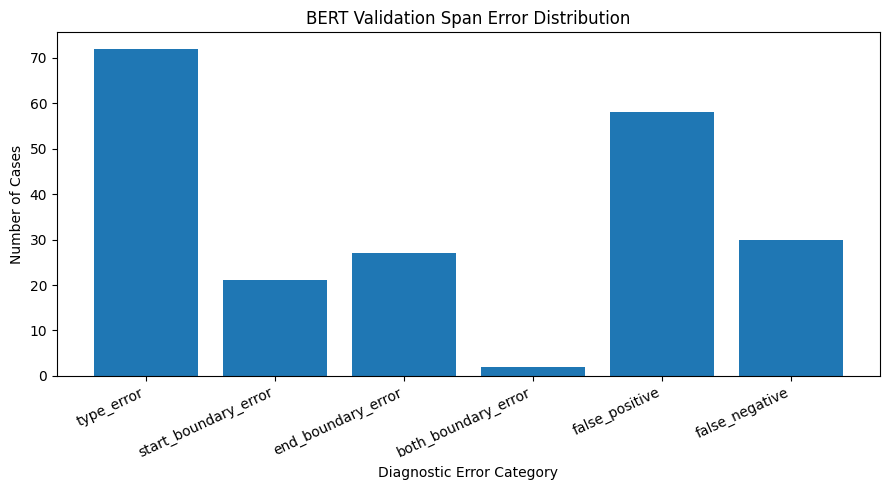

In [64]:
validation_error_plot_df = (
    validation_error_summary_df.loc[
        validation_error_summary_df[
            "Error Category"
        ]
        .ne(
            "exact_match"
        )
    ]
)


plt.figure(
    figsize=(9, 5)
)


plt.bar(
    validation_error_plot_df[
        "Error Category"
    ],
    validation_error_plot_df[
        "Count"
    ],
)


plt.title(
    "BERT Validation Span Error Distribution"
)

plt.xlabel(
    "Diagnostic Error Category"
)

plt.ylabel(
    "Number of Cases"
)

plt.xticks(
    rotation=25,
    ha="right",
)

plt.tight_layout()


error_distribution_path = (
    FIGURE_OUTPUT_DIR
    / "bert_validation_span_errors.png"
)


plt.savefig(
    error_distribution_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 14.10 Summarise Start- and End-Boundary Errors

Boundary correctness is defined only for predictions paired with a gold entity.

A prediction with both boundaries incorrect contributes to both the start-error and end-error totals.

These boundary-correctness events form the primary labels used later when evaluating whether deterministic and stochastic uncertainty signals discriminate boundary errors.

In [65]:
matched_validation_rows = (
    validation_matching_df.loc[
        validation_matching_df[
            "row_source"
        ].eq(
            "matched_pair"
        )
    ]
)


start_boundary_errors = int(
    matched_validation_rows[
        "is_start_correct"
    ]
    .eq(False)
    .sum()
)


end_boundary_errors = int(
    matched_validation_rows[
        "is_end_correct"
    ]
    .eq(False)
    .sum()
)


joint_boundary_errors = int(
    (
        matched_validation_rows[
            "is_start_correct"
        ].eq(False)
        &
        matched_validation_rows[
            "is_end_correct"
        ].eq(False)
    ).sum()
)


boundary_error_summary_df = (
    pd.DataFrame({
        "Boundary Outcome": [
            "Incorrect start boundary",
            "Incorrect end boundary",
            (
                "Both boundaries "
                "incorrect"
            ),
        ],

        "Count": [
            start_boundary_errors,
            end_boundary_errors,
            joint_boundary_errors,
        ],
    })
)


print(
    "Validation boundary-error counts:"
)

display(
    boundary_error_summary_df
)

Validation boundary-error counts:


,Boundary Outcome,Count
0,Incorrect start boundary,23
1,Incorrect end boundary,29
2,Both boundaries incorrect,2


### Section 14.11 Performance by Entity Type

In [66]:
entity_type_records = []


for entity_type in entity_types:

    type_true_positives = int(
        (
            validation_matching_df[
                "error_category"
            ].eq(
                "exact_match"
            )
            &
            validation_matching_df[
                "gold_entity_type"
            ].eq(
                entity_type
            )
        ).sum()
    )


    type_predictions = int(
        validation_matching_df[
            "predicted_entity_type"
        ]
        .eq(
            entity_type
        )
        .sum()
    )


    type_gold = int(
        validation_matching_df[
            "gold_entity_type"
        ]
        .eq(
            entity_type
        )
        .sum()
    )


    type_precision = (
        type_true_positives
        / type_predictions
        if type_predictions > 0
        else 0.0
    )


    type_recall = (
        type_true_positives
        / type_gold
        if type_gold > 0
        else 0.0
    )


    type_f1 = (
        2
        * type_precision
        * type_recall
        / (
            type_precision
            + type_recall
        )
        if (
            type_precision
            + type_recall
        ) > 0
        else 0.0
    )


    entity_type_records.append({
        "Entity Type": (
            entity_type
        ),
        "Gold Entities": (
            type_gold
        ),
        "Predicted Entities": (
            type_predictions
        ),
        "True Positives": (
            type_true_positives
        ),
        "Precision": (
            type_precision
        ),
        "Recall": (
            type_recall
        ),
        "F1": (
            type_f1
        ),
    })


entity_type_metrics_df = (
    pd.DataFrame(
        entity_type_records
    )
)


print(
    "Validation performance by entity type:"
)

display(
    entity_type_metrics_df.round(
        4
    )
)

Validation performance by entity type:


,Entity Type,Gold Entities,Predicted Entities,True Positives,Precision,Recall,F1
0,PER,969,962,943,0.9802,0.9732,0.9767
1,ORG,690,717,647,0.9024,0.9377,0.9197
2,LOC,898,890,861,0.9674,0.9588,0.9631
3,MISC,454,470,408,0.8681,0.8987,0.8831


In [67]:
strict_metrics_df.to_csv(
    METRICS_OUTPUT_DIR
    / "validation_strict_span_metrics.csv",
    index=False,
)


validation_error_summary_df.to_csv(
    METRICS_OUTPUT_DIR
    / "validation_span_outcomes.csv",
    index=False,
)


boundary_error_summary_df.to_csv(
    METRICS_OUTPUT_DIR
    / "validation_boundary_errors.csv",
    index=False,
)


entity_type_metrics_df.to_csv(
    METRICS_OUTPUT_DIR
    / "validation_entity_type_metrics.csv",
    index=False,
)


baseline_summary = {
    "model": MODEL_CHECKPOINT,
    "model_sha256": (
        reloaded_model_hash
    ),
    "seed": SEED,
    "max_length": MAX_LENGTH,

    "validation_seqeval_precision": float(
        validation_metrics[
            "validation_precision"
        ]
    ),

    "validation_seqeval_recall": float(
        validation_metrics[
            "validation_recall"
        ]
    ),

    "validation_seqeval_f1": float(
        validation_metrics[
            "validation_f1"
        ]
    ),

    "validation_strict_precision": float(
        strict_precision
    ),

    "validation_strict_recall": float(
        strict_recall
    ),

    "validation_strict_f1": float(
        strict_f1
    ),

    "validation_start_boundary_errors": int(
        start_boundary_errors
    ),

    "validation_end_boundary_errors": int(
        end_boundary_errors
    ),

    "validation_both_boundary_errors": int(
        joint_boundary_errors
    ),

    "test_evaluated": False,
}


baseline_summary_path = (
    METRICS_OUTPUT_DIR
    / "bert_baseline_summary.json"
)


with open(
    baseline_summary_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        baseline_summary,
        file,
        indent=2,
    )


print(
    "BERT deterministic baseline summary saved to:"
)

print(
    baseline_summary_path
)

BERT deterministic baseline summary saved to:
/kaggle/working/01_bert_baseline_and_uncertainty/metrics/bert_baseline_summary.json


## 15. Construct Deterministic BERT Span and Boundary Signals

The deterministic BERT outputs provide several uncertainty-oriented features before Monte Carlo Dropout is introduced.

Generic span-level uncertainty is obtained by reversing confidence-oriented quantities so that larger values consistently indicate greater uncertainty.

In addition, the BIO representation provides two architecture-specific boundary signals for a predicted entity of type \(X\).

For a predicted start position \(s\):

$$
u_s =
\frac{
P(I\text{-}X \mid s)
}{
P(B\text{-}X \mid s)
+
P(I\text{-}X \mid s)
+
\epsilon
}
$$

This measures the relative evidence that the emitted start token could instead be a continuation of an entity of the same type.

For a predicted end position \(e\):

$$
u_e =
P(I\text{-}X \mid e+1)
$$

If the predicted entity ends at the final original token of the sentence, \(u_e\) is set to zero.

The two signals are intentionally **asymmetric**:

- \(u_s\) is a normalised `B-X` versus `I-X` competition ratio at the emitted start;
- \(u_e\) is the probability of same-type continuation immediately after the emitted end.

The joint boundary signal is:

$$
u_{\mathrm{joint}}
=
\max(u_s, u_e)
$$

Larger values indicate stronger local evidence against the emitted boundary configuration.

These quantities are uncalibrated, architecture-specific boundary signals. They are not probabilities that a predicted boundary is incorrect. Their usefulness for identifying boundary errors is evaluated empirically in later analyses.

In [70]:
MAXIMUM_BIO_ENTROPY = float(
    np.log(
        len(label_names)
    )
)


FIXED_SPAN_KEYS = [
    "split",
    "source_index",
    "sentence_id",
    "sentence_index",
    "start",
    "end",
    "entity_type",
]


def add_deterministic_span_signals(
    predicted_span_df,
    token_df,
):
    """
    Attach deterministic span uncertainty and
    BIO-specific boundary signals to the fixed
    BERT prediction population.
    """

    sentence_token_groups = {
        int(sentence_index): (
            group
            .sort_values(
                "token_index"
            )
            .set_index(
                "token_index",
                drop=False,
            )
        )
        for sentence_index, group
        in token_df.groupby(
            "sentence_index",
            sort=False,
        )
    }


    records = []


    for span in predicted_span_df.to_dict(
        orient="records"
    ):

        sentence_index = int(
            span[
                "sentence_index"
            ]
        )

        start_index = int(
            span["start"]
        )

        end_index = int(
            span["end"]
        )

        entity_type = str(
            span[
                "entity_type"
            ]
        )


        sentence_tokens = (
            sentence_token_groups[
                sentence_index
            ]
        )


        start_row = (
            sentence_tokens.loc[
                start_index
            ]
        )

        end_row = (
            sentence_tokens.loc[
                end_index
            ]
        )


        updated = dict(
            span
        )


        # Generic deterministic span uncertainty.
        # Larger values consistently indicate
        # greater uncertainty.

        updated[
            "det_span_geometric_uncertainty"
        ] = (
            1.0
            - float(
                span[
                    "span_geometric_confidence_proxy"
                ]
            )
        )


        updated[
            "det_start_token_uncertainty"
        ] = (
            1.0
            - float(
                span[
                    "start_token_confidence_proxy"
                ]
            )
        )


        updated[
            "det_end_token_uncertainty"
        ] = (
            1.0
            - float(
                span[
                    "end_token_confidence_proxy"
                ]
            )
        )


        updated[
            "det_span_min_confidence_uncertainty"
        ] = (
            1.0
            - float(
                span[
                    "span_min_confidence_proxy"
                ]
            )
        )


        updated[
            "det_span_mean_confidence_uncertainty"
        ] = (
            1.0
            - float(
                span[
                    "span_mean_confidence_proxy"
                ]
            )
        )


        updated[
            "det_span_mean_margin_uncertainty"
        ] = (
            1.0
            - float(
                span[
                    "span_mean_margin_proxy"
                ]
            )
        )


        updated[
            "det_span_min_margin_uncertainty"
        ] = (
            1.0
            - float(
                span[
                    "span_min_margin_proxy"
                ]
            )
        )


        updated[
            "det_span_normalised_mean_entropy_uncertainty"
        ] = (
            float(
                span[
                    "span_mean_entropy_proxy"
                ]
            )
            / MAXIMUM_BIO_ENTROPY
        )


        updated[
            "det_span_normalised_max_entropy_uncertainty"
        ] = (
            float(
                span[
                    "span_max_entropy_proxy"
                ]
            )
            / MAXIMUM_BIO_ENTROPY
        )


        updated[
            "det_weakest_boundary_confidence_uncertainty"
        ] = (
            1.0
            - min(
                float(
                    span[
                        "start_token_confidence_proxy"
                    ]
                ),
                float(
                    span[
                        "end_token_confidence_proxy"
                    ]
                ),
            )
        )


        # BIO-specific start-boundary signal.
        #
        # u_s = P(I-X) / [P(B-X) + P(I-X)]

        b_probability_column = (
            f"prob_B_{entity_type}"
        )

        i_probability_column = (
            f"prob_I_{entity_type}"
        )


        assert (
            b_probability_column
            in token_df.columns
        )

        assert (
            i_probability_column
            in token_df.columns
        )


        start_b_probability = float(
            start_row[
                b_probability_column
            ]
        )

        start_i_probability = float(
            start_row[
                i_probability_column
            ]
        )


        start_denominator = (
            start_b_probability
            + start_i_probability
        )


        start_boundary_signal = (
            start_i_probability
            / (
                start_denominator
                + 1e-12
            )
        )


        # BIO-specific end continuation signal.
        #
        # u_e = P(I-X at token e+1)
        #
        # This is deliberately not a B-vs-I ratio.

        next_token_index = (
            end_index + 1
        )


        has_next_token = (
            next_token_index
            in sentence_tokens.index
        )


        if has_next_token:

            next_token_row = (
                sentence_tokens.loc[
                    next_token_index
                ]
            )

            end_continuation_signal = float(
                next_token_row[
                    i_probability_column
                ]
            )

        else:

            # A sentence-final entity cannot extend
            # to another original token in the sentence.
            end_continuation_signal = 0.0


        updated[
            "det_start_bio_boundary_uncertainty"
        ] = float(
            start_boundary_signal
        )


        updated[
            "det_start_bio_boundary_support"
        ] = float(
            1.0
            - start_boundary_signal
        )


        updated[
            "det_end_bio_continuation_uncertainty"
        ] = float(
            end_continuation_signal
        )


        updated[
            "det_end_bio_boundary_support"
        ] = float(
            1.0
            - end_continuation_signal
        )


        updated[
            "det_joint_bio_boundary_uncertainty"
        ] = float(
            max(
                start_boundary_signal,
                end_continuation_signal,
            )
        )


        updated[
            "end_has_next_original_token"
        ] = bool(
            has_next_token
        )


        records.append(
            updated
        )


    return pd.DataFrame(
        records
    )

In [72]:
# Section 15.2 — Build the Deterministic Span-Signal Tables
deterministic_span_signal_tables = {}

deterministic_boundary_summary_rows = []


for split_name in prediction_splits:

    deterministic_spans = (
        predicted_span_tables[
            split_name
        ]
    )


    enriched_spans = (
        add_deterministic_span_signals(
            predicted_span_df=(
                deterministic_spans
            ),
            token_df=(
                token_prediction_tables[
                    split_name
                ]
            ),
        )
    )


    # The uncertainty stage must not change the
    # deterministic prediction population.

    assert (
        len(
            enriched_spans
        )
        == len(
            deterministic_spans
        )
    )


    original_keys = set(
        deterministic_spans[
            FIXED_SPAN_KEYS
        ]
        .itertuples(
            index=False,
            name=None,
        )
    )


    enriched_keys = set(
        enriched_spans[
            FIXED_SPAN_KEYS
        ]
        .itertuples(
            index=False,
            name=None,
        )
    )


    assert (
        original_keys
        == enriched_keys
    )


    assert not enriched_spans.duplicated(
        FIXED_SPAN_KEYS
    ).any()


    # Boundary-signal range checks.

    boundary_signal_columns = [
        "det_start_bio_boundary_uncertainty",
        "det_end_bio_continuation_uncertainty",
        "det_joint_bio_boundary_uncertainty",
    ]


    for column_name in (
        boundary_signal_columns
    ):

        assert (
            enriched_spans[
                column_name
            ]
            .between(
                0.0,
                1.0,
            )
            .all()
        )


    deterministic_span_signal_tables[
        split_name
    ] = enriched_spans


    deterministic_boundary_summary_rows.append({
        "Split": split_name,

        "Fixed Predicted Spans": (
            len(
                enriched_spans
            )
        ),

        "Mean Start BIO Signal": float(
            enriched_spans[
                "det_start_bio_boundary_uncertainty"
            ].mean()
        ),

        "Mean End Continuation Signal": float(
            enriched_spans[
                "det_end_bio_continuation_uncertainty"
            ].mean()
        ),

        "Mean Joint Boundary Signal": float(
            enriched_spans[
                "det_joint_bio_boundary_uncertainty"
            ].mean()
        ),
    })


deterministic_boundary_summary_df = (
    pd.DataFrame(
        deterministic_boundary_summary_rows
    )
)


print(
    "Deterministic BERT boundary signals:"
)

display(
    deterministic_boundary_summary_df.round(
        6
    )
)


print(
    "\nDeterministic prediction "
    "population changed:",
    False,
)

Deterministic BERT boundary signals:


,Split,Fixed Predicted Spans,Mean Start BIO Signal,Mean End Continuation Signal,Mean Joint Boundary Signal
0,validation,3039,0.009329,0.002360,0.011459
1,probability_calibration,1771,0.009889,0.002059,0.011785
2,conformal_calibration,1182,0.004173,0.002032,0.006124



Deterministic prediction population changed: False


## 16. Estimate Stochastic Uncertainty with Monte Carlo Dropout

Monte Carlo Dropout is applied to the same verified and frozen BERT checkpoint.

Ten stochastic forward passes are performed for each development population.

During each pass:

- all learned parameters remain frozen;
- the parent BERT model remains globally in evaluation mode;
- only `torch.nn.Dropout` modules are activated;
- a fixed pass-specific random seed is used;
- sentence and token ordering remain unchanged.

The deterministic BERT prediction remains the reference prediction. The mean MC distribution is **not** used to create new BIO labels or new entity spans.

For each original token, the following stochastic quantities are estimated:

- mean predictive distribution;
- class-probability variance;
- predictive entropy;
- expected entropy across stochastic passes;
- mutual information;
- mean and variance for the fixed deterministic predicted class;
- fixed-label vote fraction;
- variation ratio.

Mutual information is used here as a stochastic model-disagreement signal. Although MC Dropout has often been motivated as approximate Bayesian/model uncertainty, its interpretation as a direct measure of epistemic uncertainty is not assumed here. Its empirical usefulness is evaluated later.

In [73]:
# Encourage reproducible stochastic inference.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


MC_EPSILON = 1e-12


MC_PASS_SEEDS = [
    SEED + pass_index
    for pass_index
    in range(
        MC_DROPOUT_PASSES
    )
]


def set_deterministic_evaluation_mode(
    model,
):
    """
    Place every model module in evaluation mode.
    """

    model.eval()


    active_modules = [
        name or "<root>"
        for name, module
        in model.named_modules()
        if module.training
    ]


    assert (
        model.training
        is False
    )

    assert not active_modules


def enable_mc_dropout_only(
    model,
):
    """
    Keep the parent model in evaluation mode
    while activating only torch.nn.Dropout modules.
    """

    model.eval()


    activated_dropout_modules = []


    for name, module in (
        model.named_modules()
    ):

        if isinstance(
            module,
            torch.nn.Dropout,
        ):

            module.train()

            activated_dropout_modules.append(
                name
            )


    active_non_dropout_modules = [
        name or "<root>"
        for name, module
        in model.named_modules()
        if (
            module.training
            and not isinstance(
                module,
                torch.nn.Dropout,
            )
        )
    ]


    assert (
        model.training
        is False
    )

    assert (
        activated_dropout_modules
    )

    assert not (
        active_non_dropout_modules
    )


    return (
        activated_dropout_modules
    )

In [74]:
# The model must still contain no trainable parameters.
trainable_parameter_count = sum(
    parameter.numel()
    for parameter
    in model.parameters()
    if parameter.requires_grad
)


assert (
    trainable_parameter_count
    == 0
)


dropout_module_records = [
    {
        "Module": name,
        "Dropout Probability": float(
            module.p
        ),
    }
    for name, module
    in model.named_modules()
    if isinstance(
        module,
        torch.nn.Dropout,
    )
]


dropout_module_df = pd.DataFrame(
    dropout_module_records
)


assert (
    len(
        dropout_module_df
    )
    > 0
)


# Test the stochastic model mode.
activated_dropout_names = (
    enable_mc_dropout_only(
        model
    )
)


active_dropout_count = sum(
    isinstance(
        module,
        torch.nn.Dropout,
    )
    and module.training
    for module
    in model.modules()
)


active_non_dropout_count = sum(
    (
        not isinstance(
            module,
            torch.nn.Dropout,
        )
    )
    and module.training
    for module
    in model.modules()
)


assert (
    active_dropout_count
    == len(
        dropout_module_df
    )
)

assert (
    active_non_dropout_count
    == 0
)


# Return to deterministic mode before
# beginning the actual MC procedure.
set_deterministic_evaluation_mode(
    model
)


model_mode_summary_df = pd.DataFrame({
    "Check": [
        "Trainable parameters",
        "Dropout modules available",
        "Dropout modules activated in MC mode",
        "Non-dropout modules activated",
        "Stored model mode after check",
    ],

    "Value": [
        trainable_parameter_count,
        len(
            dropout_module_df
        ),
        active_dropout_count,
        active_non_dropout_count,
        "evaluation",
    ],
})


print(
    "BERT MC-Dropout model-mode verification:"
)

display(
    model_mode_summary_df
)


print(
    "\nDropout probabilities:",
    sorted(
        dropout_module_df[
            "Dropout Probability"
        ]
        .unique()
        .tolist()
    ),
)

BERT MC-Dropout model-mode verification:


,Check,Value
0,Trainable parameters,0
1,Dropout modules available,38
2,Dropout modules activated in MC mode,38
3,Non-dropout modules activated,0
4,Stored model mode after check,evaluation



Dropout probabilities: [0.1]


### 16.3 Create Ordered MC-Dropout DataLoaders

Monte Carlo Dropout operates on the same tokenised populations created earlier in this notebook.

Batches are not shuffled. Original sentence and token ordering therefore remains identical to the deterministic prediction tables.

In [75]:
inference_dataloaders = {
    split_name: DataLoader(
        dataset=(
            model_dataset[
                split_name
            ]
        ),

        batch_size=(
            MC_EVAL_BATCH_SIZE
        ),

        shuffle=False,
        drop_last=False,

        num_workers=(
            NUM_WORKERS
        ),

        pin_memory=(
            DEVICE.type
            == "cuda"
        ),

        collate_fn=(
            data_collator
        ),
    )

    for split_name
    in prediction_splits
}


mc_loader_summary_df = pd.DataFrame({
    "Split": prediction_splits,

    "Sentences": [
        len(
            model_dataset[
                split_name
            ]
        )
        for split_name
        in prediction_splits
    ],

    "Batches": [
        len(
            inference_dataloaders[
                split_name
            ]
        )
        for split_name
        in prediction_splits
    ],

    "Batch Size": (
        MC_EVAL_BATCH_SIZE
    ),

    "Shuffled": False,
})


display(
    mc_loader_summary_df
)

,Split,Sentences,Batches,Batch Size,Shuffled
0,validation,1625,102,16,False
1,probability_calibration,975,61,16,False
2,conformal_calibration,650,41,16,False


### 16.4 Aggregate Stochastic Forward Passes

Full pass-level probability tensors are not retained.

Instead, online sums, squared sums, entropy sums and class-vote counts are accumulated across the ten stochastic passes. These are sufficient to recover the uncertainty statistics required downstream while avoiding unnecessary storage.

A SHA-256 digest of each stochastic pass is also recorded as an integrity check that the seeded dropout passes genuinely produce distinct probability outputs.

In [76]:
def run_mc_dropout_aggregation(
    split_name,
):
    """
    Aggregate repeated stochastic forward passes
    at original-token level without redefining the
    deterministic BERT predictions.
    """

    dataloader = (
        inference_dataloaders[
            split_name
        ]
    )


    number_of_tokens = int(
        split_information[
            "identities"
        ][
            split_name
        ][
            "tokens"
        ]
    )


    number_of_classes = (
        len(label_names)
    )


    # Fixed deterministic labels from Section 13.
    fixed_token_df = (
        token_prediction_tables[
            split_name
        ]
        .sort_values(
            [
                "sentence_index",
                "token_index",
            ]
        )
        .reset_index(
            drop=True
        )
    )


    assert (
        len(
            fixed_token_df
        )
        == number_of_tokens
    )


    deterministic_ids = (
        fixed_token_df[
            "predicted_label_id"
        ]
        .to_numpy(
            dtype=np.int16
        )
    )


    probability_sum = np.zeros(
        (
            number_of_tokens,
            number_of_classes,
        ),
        dtype=np.float64,
    )


    probability_square_sum = (
        np.zeros_like(
            probability_sum
        )
    )


    entropy_sum = np.zeros(
        number_of_tokens,
        dtype=np.float64,
    )


    vote_counts = np.zeros(
        (
            number_of_tokens,
            number_of_classes,
        ),
        dtype=np.int16,
    )


    pass_seconds = []
    pass_probability_hashes = []


    activated_dropout_modules = (
        enable_mc_dropout_only(
            model
        )
    )


    for (
        pass_index,
        pass_seed,
    ) in enumerate(
        MC_PASS_SEEDS
    ):

        random.seed(
            pass_seed
        )

        np.random.seed(
            pass_seed
        )

        torch.manual_seed(
            pass_seed
        )


        if torch.cuda.is_available():

            torch.cuda.manual_seed_all(
                pass_seed
            )


        if DEVICE.type == "cuda":

            torch.cuda.synchronize()


        pass_start_time = (
            time.perf_counter()
        )


        token_cursor = 0

        pass_digest = (
            hashlib.sha256()
        )


        with torch.no_grad():

            for batch in dataloader:

                labels = (
                    batch[
                        "labels"
                    ]
                )


                model_inputs = {
                    "input_ids": (
                        batch[
                            "input_ids"
                        ].to(
                            DEVICE
                        )
                    ),

                    "token_type_ids": (
                        batch[
                            "token_type_ids"
                        ].to(
                            DEVICE
                        )
                    ),

                    "attention_mask": (
                        batch[
                            "attention_mask"
                        ].to(
                            DEVICE
                        )
                    ),
                }


                logits = (
                    model(
                        **model_inputs
                    ).logits
                )


                probabilities = (
                    torch.softmax(
                        logits.float(),
                        dim=-1,
                    )
                    .cpu()
                )


                stochastic_predictions = (
                    probabilities.argmax(
                        dim=-1
                    )
                )


                pass_entropy = (
                    -torch.sum(
                        probabilities
                        * torch.log(
                            probabilities
                            .clamp_min(
                                MC_EPSILON
                            )
                        ),
                        dim=-1,
                    )
                )


                for row_index in range(
                    labels.shape[0]
                ):

                    evaluation_mask = (
                        labels[
                            row_index
                        ]
                        != -100
                    )


                    row_probabilities = (
                        probabilities[
                            row_index
                        ][
                            evaluation_mask
                        ]
                        .numpy()
                        .astype(
                            np.float64
                        )
                    )


                    row_predictions = (
                        stochastic_predictions[
                            row_index
                        ][
                            evaluation_mask
                        ]
                        .numpy()
                        .astype(
                            np.int16
                        )
                    )


                    row_entropy = (
                        pass_entropy[
                            row_index
                        ][
                            evaluation_mask
                        ]
                        .numpy()
                        .astype(
                            np.float64
                        )
                    )


                    # Record stochastic pass identity.
                    pass_digest.update(
                        row_probabilities
                        .astype(
                            np.float32
                        )
                        .tobytes()
                    )


                    row_count = (
                        len(
                            row_predictions
                        )
                    )


                    row_slice = slice(
                        token_cursor,
                        token_cursor
                        + row_count,
                    )


                    probability_sum[
                        row_slice
                    ] += (
                        row_probabilities
                    )


                    probability_square_sum[
                        row_slice
                    ] += np.square(
                        row_probabilities
                    )


                    entropy_sum[
                        row_slice
                    ] += row_entropy


                    row_global_indices = (
                        np.arange(
                            token_cursor,
                            token_cursor
                            + row_count,
                        )
                    )


                    vote_counts[
                        row_global_indices,
                        row_predictions,
                    ] += 1


                    token_cursor += (
                        row_count
                    )


        assert (
            token_cursor
            == number_of_tokens
        )


        if DEVICE.type == "cuda":

            torch.cuda.synchronize()


        elapsed_seconds = (
            time.perf_counter()
            - pass_start_time
        )


        pass_seconds.append(
            elapsed_seconds
        )


        pass_probability_hashes.append(
            pass_digest.hexdigest()
        )


        print(
            f"{split_name}: MC pass "
            f"{pass_index + 1}/"
            f"{MC_DROPOUT_PASSES} "
            f"completed in "
            f"{elapsed_seconds:.2f}s"
        )


    # Verify the stochastic passes were genuinely distinct.

    assert (
        len(
            set(
                pass_probability_hashes
            )
        )
        == MC_DROPOUT_PASSES
    ), (
        "One or more MC passes produced "
        "identical probability outputs."
    )


    # Aggregate probabilities.
    # 

    mean_probabilities = (
        probability_sum
        / MC_DROPOUT_PASSES
    )


    mean_squared_probabilities = (
        probability_square_sum
        / MC_DROPOUT_PASSES
    )


    class_probability_variance = (
        mean_squared_probabilities
        - np.square(
            mean_probabilities
        )
    )


    # Tiny negative values can arise only from
    # floating-point subtraction.
    assert (
        class_probability_variance.min()
        >= -1e-10
    )


    class_probability_variance = (
        np.clip(
            class_probability_variance,
            0.0,
            None,
        )
    )


    # At least some probabilities must vary
    # if dropout was genuinely stochastic.
    assert np.any(
        class_probability_variance
        > 0.0
    )


    # Predictive entropy.
    #
    # H(E[p(y|x,w)])

    safe_mean_probabilities = (
        np.clip(
            mean_probabilities,
            MC_EPSILON,
            1.0,
        )
    )


    predictive_entropy = (
        -np.sum(
            mean_probabilities
            * np.log(
                safe_mean_probabilities
            ),
            axis=1,
        )
    )


    # 
    # Expected entropy.
    #
    # E[H(p(y|x,w))]

    expected_entropy = (
        entropy_sum
        / MC_DROPOUT_PASSES
    )


    # Mutual information / stochastic disagreement.
    #
    # H(E[p]) - E[H(p)]

    raw_mutual_information = (
        predictive_entropy
        - expected_entropy
    )


    assert (
        raw_mutual_information.min()
        >= -1e-6
    )


    mutual_information = (
        np.clip(
            raw_mutual_information,
            0.0,
            None,
        )
    )


    token_indices = np.arange(
        number_of_tokens
    )


    # Statistics for the fixed deterministic class.
    fixed_class_mean_probability = (
        mean_probabilities[
            token_indices,
            deterministic_ids,
        ]
    )


    fixed_class_probability_variance = (
        class_probability_variance[
            token_indices,
            deterministic_ids,
        ]
    )


    fixed_class_probability_std = (
        np.sqrt(
            fixed_class_probability_variance
        )
    )


    fixed_label_vote_fraction = (
        vote_counts[
            token_indices,
            deterministic_ids,
        ]
        / MC_DROPOUT_PASSES
    )


    modal_vote_fraction = (
        vote_counts.max(
            axis=1
        )
        / MC_DROPOUT_PASSES
    )


    variation_ratio = (
        1.0
        - modal_vote_fraction
    )


    # This is retained only as a stability diagnostic.
    # It does NOT replace the deterministic prediction.
    mean_distribution_predicted_ids = (
        mean_probabilities.argmax(
            axis=1
        )
        .astype(
            np.int16
        )
    )


    mean_distribution_disagreement = (
        mean_distribution_predicted_ids
        != deterministic_ids
    )


    # -----------------------------------------------------
    # Final numerical checks.
    # -----------------------------------------------------

    assert np.allclose(
        mean_probabilities.sum(
            axis=1
        ),
        1.0,
        atol=1e-5,
    )


    assert np.all(
        mutual_information
        >= 0.0
    )


    assert np.all(
        fixed_class_probability_variance
        >= 0.0
    )


    assert np.all(
        (
            variation_ratio
            >= 0.0
        )
        &
        (
            variation_ratio
            <= 1.0
        )
    )


    # Return the model to standard deterministic mode.
    set_deterministic_evaluation_mode(
        model
    )


    return {
        "mean_probabilities": (
            mean_probabilities.astype(
                np.float32
            )
        ),

        "class_probability_variance": (
            class_probability_variance
            .astype(
                np.float32
            )
        ),

        "predictive_entropy": (
            predictive_entropy.astype(
                np.float32
            )
        ),

        "expected_entropy": (
            expected_entropy.astype(
                np.float32
            )
        ),

        "mutual_information": (
            mutual_information.astype(
                np.float32
            )
        ),

        "fixed_class_mean_probability": (
            fixed_class_mean_probability
            .astype(
                np.float32
            )
        ),

        "fixed_class_probability_variance": (
            fixed_class_probability_variance
            .astype(
                np.float32
            )
        ),

        "fixed_class_probability_std": (
            fixed_class_probability_std
            .astype(
                np.float32
            )
        ),

        "fixed_label_vote_fraction": (
            fixed_label_vote_fraction
            .astype(
                np.float32
            )
        ),

        "variation_ratio": (
            variation_ratio.astype(
                np.float32
            )
        ),

        "mean_distribution_predicted_ids": (
            mean_distribution_predicted_ids
        ),

        "mean_distribution_disagreement": (
            mean_distribution_disagreement
            .astype(bool)
        ),

        "vote_counts": (
            vote_counts
        ),

        "pass_seconds": (
            pass_seconds
        ),

        "pass_probability_hashes": (
            pass_probability_hashes
        ),

        "activated_dropout_modules": (
            activated_dropout_modules
        ),
    }


print(
    "MC-Dropout aggregation helper created."
)

MC-Dropout aggregation helper created.


### 16.5 Run MC Dropout on the Three Frozen Populations

Stochastic features are generated for validation, probability calibration and conformal calibration so that later notebooks can consume the same frozen uncertainty representation.

Only validation outcomes are interpreted in this notebook. Calibration populations are processed for feature generation only.

In [77]:
mc_results = {}

mc_runtime_rows = []


for split_name in prediction_splits:

    print(
        f"\nRunning MC Dropout for "
        f"{split_name}..."
    )


    split_results = (
        run_mc_dropout_aggregation(
            split_name
        )
    )


    mc_results[
        split_name
    ] = split_results


    array_path = (
        MC_ARRAY_OUTPUT_DIR
        / (
            f"{split_name}_"
            "bert_mc_dropout_arrays.npz"
        )
    )


    np.savez_compressed(
        array_path,

        mean_probabilities=(
            split_results[
                "mean_probabilities"
            ]
        ),

        class_probability_variance=(
            split_results[
                "class_probability_variance"
            ]
        ),

        predictive_entropy=(
            split_results[
                "predictive_entropy"
            ]
        ),

        expected_entropy=(
            split_results[
                "expected_entropy"
            ]
        ),

        mutual_information=(
            split_results[
                "mutual_information"
            ]
        ),

        fixed_class_mean_probability=(
            split_results[
                "fixed_class_mean_probability"
            ]
        ),

        fixed_class_probability_variance=(
            split_results[
                "fixed_class_probability_variance"
            ]
        ),

        fixed_class_probability_std=(
            split_results[
                "fixed_class_probability_std"
            ]
        ),

        fixed_label_vote_fraction=(
            split_results[
                "fixed_label_vote_fraction"
            ]
        ),

        variation_ratio=(
            split_results[
                "variation_ratio"
            ]
        ),

        mean_distribution_predicted_ids=(
            split_results[
                "mean_distribution_predicted_ids"
            ]
        ),

        mean_distribution_disagreement=(
            split_results[
                "mean_distribution_disagreement"
            ]
        ),

        vote_counts=(
            split_results[
                "vote_counts"
            ]
        ),
    )


    mc_runtime_rows.append({
        "Split": split_name,

        "Passes": (
            MC_DROPOUT_PASSES
        ),

        "Tokens": int(
            split_information[
                "identities"
            ][
                split_name
            ][
                "tokens"
            ]
        ),

        "Unique Stochastic Passes": (
            len(
                set(
                    split_results[
                        "pass_probability_hashes"
                    ]
                )
            )
        ),

        "Total Seconds": float(
            np.sum(
                split_results[
                    "pass_seconds"
                ]
            )
        ),

        "Mean Seconds per Pass": float(
            np.mean(
                split_results[
                    "pass_seconds"
                ]
            )
        ),

        "Mean-Distribution Disagreements": int(
            split_results[
                "mean_distribution_disagreement"
            ].sum()
        ),
    })


mc_runtime_df = pd.DataFrame(
    mc_runtime_rows
)


mc_runtime_df.to_csv(
    METRICS_OUTPUT_DIR
    / "mc_dropout_runtime_summary.csv",
    index=False,
)


print(
    "\nMC-Dropout runtime and "
    "stochasticity summary:"
)

display(
    mc_runtime_df.round(
        3
    )
)


print(
    "\nDeterministic prediction "
    "population redefined:",
    False,
)

print(
    "Official test processed:",
    False,
)


Running MC Dropout for validation...
validation: MC pass 1/10 completed in 5.86s
validation: MC pass 2/10 completed in 5.92s
validation: MC pass 3/10 completed in 6.06s
validation: MC pass 4/10 completed in 6.25s
validation: MC pass 5/10 completed in 6.29s
validation: MC pass 6/10 completed in 6.20s
validation: MC pass 7/10 completed in 6.05s
validation: MC pass 8/10 completed in 5.95s
validation: MC pass 9/10 completed in 5.93s
validation: MC pass 10/10 completed in 5.90s

Running MC Dropout for probability_calibration...
probability_calibration: MC pass 1/10 completed in 3.52s
probability_calibration: MC pass 2/10 completed in 3.51s
probability_calibration: MC pass 3/10 completed in 3.52s
probability_calibration: MC pass 4/10 completed in 3.52s
probability_calibration: MC pass 5/10 completed in 3.52s
probability_calibration: MC pass 6/10 completed in 3.53s
probability_calibration: MC pass 7/10 completed in 3.54s
probability_calibration: MC pass 8/10 completed in 3.55s
probability_ca

,Split,Passes,Tokens,Unique Stochastic Passes,Total Seconds,Mean Seconds per Pass,Mean-Distribution Disagreements
0,validation,10,26021,10,60.415,6.042,46
1,probability_calibration,10,15726,10,35.370,3.537,25
2,conformal_calibration,10,9615,10,24.522,2.452,15



Deterministic prediction population redefined: False
Official test processed: False


### 16.6 Attach MC Statistics to the Fixed Original-Word Predictions

One output row is retained for every deterministic original-word prediction.

The nine-class mean MC distribution and derived stochastic uncertainty statistics are attached to those existing rows.

The argmax of the mean MC distribution is retained only as a stability diagnostic and does not replace the deterministic BERT prediction.

In [78]:
MC_MEAN_PROBABILITY_COLUMNS = [
    f"mc_mean_{column_name}"
    for column_name
    in PROBABILITY_COLUMNS
]


token_uncertainty_tables = {}

token_uncertainty_summary_rows = []


for split_name in prediction_splits:

    baseline_tokens = (
        token_prediction_tables[
            split_name
        ]
        .sort_values(
            [
                "sentence_index",
                "token_index",
            ]
        )
        .reset_index(
            drop=True
        )
        .copy()
    )


    split_mc = (
        mc_results[
            split_name
        ]
    )


    assert (
        len(
            baseline_tokens
        )
        == len(
            split_mc[
                "predictive_entropy"
            ]
        )
    )


    token_uncertainty_df = (
        baseline_tokens.copy()
    )


    # Nine-class mean stochastic probabilities.
    for (
        class_index,
        column_name,
    ) in enumerate(
        MC_MEAN_PROBABILITY_COLUMNS
    ):

        token_uncertainty_df[
            column_name
        ] = (
            split_mc[
                "mean_probabilities"
            ][
                :,
                class_index,
            ]
        )


    token_uncertainty_df[
        "mc_predictive_entropy"
    ] = (
        split_mc[
            "predictive_entropy"
        ]
    )


    token_uncertainty_df[
        "mc_expected_entropy"
    ] = (
        split_mc[
            "expected_entropy"
        ]
    )


    token_uncertainty_df[
        "mc_mutual_information"
    ] = (
        split_mc[
            "mutual_information"
        ]
    )


    token_uncertainty_df[
        "mc_normalised_predictive_entropy"
    ] = (
        token_uncertainty_df[
            "mc_predictive_entropy"
        ]
        / MAXIMUM_BIO_ENTROPY
    )


    token_uncertainty_df[
        "mc_normalised_expected_entropy"
    ] = (
        token_uncertainty_df[
            "mc_expected_entropy"
        ]
        / MAXIMUM_BIO_ENTROPY
    )


    token_uncertainty_df[
        "mc_normalised_mutual_information"
    ] = (
        token_uncertainty_df[
            "mc_mutual_information"
        ]
        / MAXIMUM_BIO_ENTROPY
    )


    token_uncertainty_df[
        "mc_fixed_class_mean_probability"
    ] = (
        split_mc[
            "fixed_class_mean_probability"
        ]
    )


    token_uncertainty_df[
        "mc_fixed_class_probability_variance"
    ] = (
        split_mc[
            "fixed_class_probability_variance"
        ]
    )


    token_uncertainty_df[
        "mc_fixed_class_probability_std"
    ] = (
        split_mc[
            "fixed_class_probability_std"
        ]
    )


    token_uncertainty_df[
        "mc_fixed_label_vote_fraction"
    ] = (
        split_mc[
            "fixed_label_vote_fraction"
        ]
    )


    token_uncertainty_df[
        "mc_variation_ratio"
    ] = (
        split_mc[
            "variation_ratio"
        ]
    )


    token_uncertainty_df[
        "mc_mean_distribution_predicted_label_id"
    ] = (
        split_mc[
            "mean_distribution_predicted_ids"
        ]
    )


    token_uncertainty_df[
        "mc_mean_distribution_predicted_bio_label"
    ] = [
        id2label[
            int(label_id)
        ]
        for label_id
        in split_mc[
            "mean_distribution_predicted_ids"
        ]
    ]


    token_uncertainty_df[
        "mc_mean_distribution_disagrees_with_fixed_prediction"
    ] = (
        split_mc[
            "mean_distribution_disagreement"
        ]
    )


    # Numerical range checks.

    normalised_columns = [
        "mc_normalised_predictive_entropy",
        "mc_normalised_expected_entropy",
        "mc_normalised_mutual_information",
    ]


    normalised_values = (
        token_uncertainty_df[
            normalised_columns
        ]
        .to_numpy(
            dtype=float
        )
    )


    assert np.all(
        normalised_values
        >= -1e-8
    )

    assert np.all(
        normalised_values
        <= 1.0 + 1e-8
    )


    assert (
        token_uncertainty_df[
            "mc_fixed_label_vote_fraction"
        ]
        .between(
            0.0,
            1.0,
        )
        .all()
    )


    assert (
        token_uncertainty_df[
            "mc_variation_ratio"
        ]
        .between(
            0.0,
            1.0,
        )
        .all()
    )


    token_uncertainty_tables[
        split_name
    ] = (
        token_uncertainty_df
    )


    output_path = (
        TOKEN_UNCERTAINTY_DIR
        / (
            f"{split_name}_"
            "bert_token_uncertainty.csv"
        )
    )


    token_uncertainty_df.to_csv(
        output_path,
        index=False,
    )


    token_uncertainty_summary_rows.append({
        "Split": split_name,

        "Rows": len(
            token_uncertainty_df
        ),

        "Mean Predictive Entropy": float(
            token_uncertainty_df[
                "mc_predictive_entropy"
            ].mean()
        ),

        "Mean Mutual Information": float(
            token_uncertainty_df[
                "mc_mutual_information"
            ].mean()
        ),

        "Mean Fixed-Label Vote Fraction": float(
            token_uncertainty_df[
                "mc_fixed_label_vote_fraction"
            ].mean()
        ),

        "Mean-Distribution Disagreements": int(
            token_uncertainty_df[
                "mc_mean_distribution_disagrees_with_fixed_prediction"
            ].sum()
        ),
    })


token_uncertainty_summary_df = (
    pd.DataFrame(
        token_uncertainty_summary_rows
    )
)


print(
    "Original-token MC uncertainty outputs:"
)

display(
    token_uncertainty_summary_df.round(
        6
    )
)

Original-token MC uncertainty outputs:


,Split,Rows,Mean Predictive Entropy,Mean Mutual Information,Mean Fixed-Label Vote Fraction,Mean-Distribution Disagreements
0,validation,26021,0.026931,0.003011,0.996434,46
1,probability_calibration,15726,0.026562,0.002924,0.996471,25
2,conformal_calibration,9615,0.025702,0.002553,0.996661,15


### 16.7 Aggregate Stochastic Uncertainty onto the Fixed BERT Spans

Monte Carlo Dropout does not produce a new span population.

Instead, token-level stochastic statistics are aggregated over the tokens already belonging to each deterministic BERT span.

Endpoint statistics are retained separately for the deterministic start and end tokens.

This produces one unified representation containing deterministic and stochastic uncertainty for exactly the same emitted entity spans.

In [80]:
def aggregate_mc_span_uncertainty(
    deterministic_span_df,
    token_uncertainty_df,
):
    """
    Attach MC-Dropout statistics to the fixed
    deterministic BERT span population.
    """

    token_groups = {
        int(sentence_index): (
            group
            .sort_values(
                "token_index"
            )
            .set_index(
                "token_index",
                drop=False,
            )
        )
        for sentence_index, group
        in token_uncertainty_df.groupby(
            "sentence_index",
            sort=False,
        )
    }


    enriched_records = []


    for span in deterministic_span_df.to_dict(
        orient="records"
    ):

        sentence_index = int(
            span[
                "sentence_index"
            ]
        )

        start_index = int(
            span["start"]
        )

        end_index = int(
            span["end"]
        )


        sentence_tokens = (
            token_groups[
                sentence_index
            ]
        )


        expected_token_indices = list(
            range(
                start_index,
                end_index + 1,
            )
        )


        span_token_rows = (
            sentence_tokens.loc[
                expected_token_indices
            ]
        )


        assert (
            span_token_rows[
                "token_index"
            ]
            .astype(int)
            .tolist()
            == expected_token_indices
        )


        assert (
            len(
                span_token_rows
            )
            == int(
                span[
                    "token_count"
                ]
            )
        )


        fixed_probability_values = (
            span_token_rows[
                "mc_fixed_class_mean_probability"
            ]
            .to_numpy(
                dtype=float
            )
        )


        predictive_entropy_values = (
            span_token_rows[
                "mc_predictive_entropy"
            ]
            .to_numpy(
                dtype=float
            )
        )


        expected_entropy_values = (
            span_token_rows[
                "mc_expected_entropy"
            ]
            .to_numpy(
                dtype=float
            )
        )


        mutual_information_values = (
            span_token_rows[
                "mc_mutual_information"
            ]
            .to_numpy(
                dtype=float
            )
        )


        normalised_predictive_entropy_values = (
            span_token_rows[
                "mc_normalised_predictive_entropy"
            ]
            .to_numpy(
                dtype=float
            )
        )


        normalised_mutual_information_values = (
            span_token_rows[
                "mc_normalised_mutual_information"
            ]
            .to_numpy(
                dtype=float
            )
        )


        variance_values = (
            span_token_rows[
                "mc_fixed_class_probability_variance"
            ]
            .to_numpy(
                dtype=float
            )
        )


        variation_ratio_values = (
            span_token_rows[
                "mc_variation_ratio"
            ]
            .to_numpy(
                dtype=float
            )
        )


        vote_fraction_values = (
            span_token_rows[
                "mc_fixed_label_vote_fraction"
            ]
            .to_numpy(
                dtype=float
            )
        )


        start_row = (
            span_token_rows.iloc[
                0
            ]
        )

        end_row = (
            span_token_rows.iloc[
                -1
            ]
        )


        updated = dict(
            span
        )


        # 
        # Whole-span stochastic summaries.

        updated[
            "mc_span_geometric_fixed_label_probability"
        ] = geometric_mean(
            fixed_probability_values
        )


        updated[
            "mc_span_geometric_fixed_label_uncertainty"
        ] = (
            1.0
            - updated[
                "mc_span_geometric_fixed_label_probability"
            ]
        )


        updated[
            "mc_span_min_fixed_label_probability"
        ] = float(
            fixed_probability_values.min()
        )


        updated[
            "mc_span_mean_predictive_entropy"
        ] = float(
            predictive_entropy_values.mean()
        )


        updated[
            "mc_span_max_predictive_entropy"
        ] = float(
            predictive_entropy_values.max()
        )


        updated[
            "mc_span_mean_expected_entropy"
        ] = float(
            expected_entropy_values.mean()
        )


        updated[
            "mc_span_mean_mutual_information"
        ] = float(
            mutual_information_values.mean()
        )


        updated[
            "mc_span_max_mutual_information"
        ] = float(
            mutual_information_values.max()
        )


        updated[
            "mc_span_mean_normalised_predictive_entropy"
        ] = float(
            normalised_predictive_entropy_values.mean()
        )


        updated[
            "mc_span_max_normalised_predictive_entropy"
        ] = float(
            normalised_predictive_entropy_values.max()
        )


        updated[
            "mc_span_mean_normalised_mutual_information"
        ] = float(
            normalised_mutual_information_values.mean()
        )


        updated[
            "mc_span_max_normalised_mutual_information"
        ] = float(
            normalised_mutual_information_values.max()
        )


        updated[
            "mc_span_mean_fixed_class_variance"
        ] = float(
            variance_values.mean()
        )


        updated[
            "mc_span_max_fixed_class_variance"
        ] = float(
            variance_values.max()
        )


        updated[
            "mc_span_mean_variation_ratio"
        ] = float(
            variation_ratio_values.mean()
        )


        updated[
            "mc_span_max_variation_ratio"
        ] = float(
            variation_ratio_values.max()
        )


        updated[
            "mc_span_min_fixed_label_vote_fraction"
        ] = float(
            vote_fraction_values.min()
        )


        # 
        # Start endpoint.
        # 

        updated[
            "mc_start_fixed_class_mean_probability"
        ] = float(
            start_row[
                "mc_fixed_class_mean_probability"
            ]
        )


        updated[
            "mc_start_predictive_entropy"
        ] = float(
            start_row[
                "mc_predictive_entropy"
            ]
        )


        updated[
            "mc_start_mutual_information"
        ] = float(
            start_row[
                "mc_mutual_information"
            ]
        )


        updated[
            "mc_start_normalised_mutual_information"
        ] = float(
            start_row[
                "mc_normalised_mutual_information"
            ]
        )


        updated[
            "mc_start_fixed_class_variance"
        ] = float(
            start_row[
                "mc_fixed_class_probability_variance"
            ]
        )


        updated[
            "mc_start_fixed_label_vote_fraction"
        ] = float(
            start_row[
                "mc_fixed_label_vote_fraction"
            ]
        )


        updated[
            "mc_start_variation_ratio"
        ] = float(
            start_row[
                "mc_variation_ratio"
            ]
        )


        # End endpoint.

        updated[
            "mc_end_fixed_class_mean_probability"
        ] = float(
            end_row[
                "mc_fixed_class_mean_probability"
            ]
        )


        updated[
            "mc_end_predictive_entropy"
        ] = float(
            end_row[
                "mc_predictive_entropy"
            ]
        )


        updated[
            "mc_end_mutual_information"
        ] = float(
            end_row[
                "mc_mutual_information"
            ]
        )


        updated[
            "mc_end_normalised_mutual_information"
        ] = float(
            end_row[
                "mc_normalised_mutual_information"
            ]
        )


        updated[
            "mc_end_fixed_class_variance"
        ] = float(
            end_row[
                "mc_fixed_class_probability_variance"
            ]
        )


        updated[
            "mc_end_fixed_label_vote_fraction"
        ] = float(
            end_row[
                "mc_fixed_label_vote_fraction"
            ]
        )


        updated[
            "mc_end_variation_ratio"
        ] = float(
            end_row[
                "mc_variation_ratio"
            ]
        )


        enriched_records.append(
            updated
        )


    return pd.DataFrame(
        enriched_records
    )

### 16.8 Derive BIO Boundary Signals from the Mean MC Distribution

The same BERT-specific boundary construction is applied to the mean predictive distribution obtained across the Monte Carlo Dropout passes.

Let the mean class probability across \(T\) stochastic forward passes be:

$$
\bar{P}(y \mid x)
=
\frac{1}{T}
\sum_{t=1}^{T}
P_t(y \mid x)
$$

For a deterministic predicted entity of type \(X\) beginning at position \(s\), the MC-based start-boundary signal is:

$$
u_s^{\mathrm{MC}}
=
\frac{
\bar{P}(I\text{-}X \mid s)
}{
\bar{P}(B\text{-}X \mid s)
+
\bar{P}(I\text{-}X \mid s)
+
\epsilon
}
$$

For a deterministic predicted entity ending at position \(e\), the MC-based end-boundary signal is:

$$
u_e^{\mathrm{MC}}
=
\bar{P}(I\text{-}X \mid e+1)
$$

If the predicted entity ends at the final original token of the sentence, \(u_e^{\mathrm{MC}}\) is set to zero.

The corresponding joint signal is:

$$
u_{\mathrm{joint}}^{\mathrm{MC}}
=
\max
\left(
u_s^{\mathrm{MC}},
u_e^{\mathrm{MC}}
\right)
$$

As in the deterministic construction, the start and end quantities are intentionally asymmetric:

- \(u_s^{\mathrm{MC}}\) is a `B-X` versus `I-X` competition ratio;
- \(u_e^{\mathrm{MC}}\) is a same-type continuation probability.

The mean MC distribution is used only to derive uncertainty features for the existing deterministic BERT spans. It does not redefine the predicted BIO labels or entity spans.

These quantities are uncalibrated boundary signals and are not interpreted as probabilities of boundary error.

In [81]:
def add_mc_bio_boundary_signals(
    span_df,
    token_uncertainty_df,
):
    """
    Add BIO-specific boundary signals derived
    from the mean MC predictive distribution.
    """

    sentence_token_groups = {
        int(sentence_index): (
            group
            .sort_values(
                "token_index"
            )
            .set_index(
                "token_index",
                drop=False,
            )
        )
        for sentence_index, group
        in token_uncertainty_df.groupby(
            "sentence_index",
            sort=False,
        )
    }


    records = []


    for span in span_df.to_dict(
        orient="records"
    ):

        sentence_index = int(
            span[
                "sentence_index"
            ]
        )

        start_index = int(
            span["start"]
        )

        end_index = int(
            span["end"]
        )

        entity_type = str(
            span[
                "entity_type"
            ]
        )


        sentence_tokens = (
            sentence_token_groups[
                sentence_index
            ]
        )


        start_row = (
            sentence_tokens.loc[
                start_index
            ]
        )


        mc_b_column = (
            f"mc_mean_prob_B_{entity_type}"
        )

        mc_i_column = (
            f"mc_mean_prob_I_{entity_type}"
        )


        assert (
            mc_b_column
            in token_uncertainty_df.columns
        )

        assert (
            mc_i_column
            in token_uncertainty_df.columns
        )


        mc_start_b = float(
            start_row[
                mc_b_column
            ]
        )

        mc_start_i = float(
            start_row[
                mc_i_column
            ]
        )


        mc_start_signal = (
            mc_start_i
            / (
                mc_start_b
                + mc_start_i
                + 1e-12
            )
        )


        next_token_index = (
            end_index + 1
        )


        has_next_token = (
            next_token_index
            in sentence_tokens.index
        )


        if has_next_token:

            next_row = (
                sentence_tokens.loc[
                    next_token_index
                ]
            )


            mc_end_signal = float(
                next_row[
                    mc_i_column
                ]
            )

        else:

            mc_end_signal = 0.0


        updated = dict(
            span
        )


        updated[
            "mc_start_bio_boundary_uncertainty"
        ] = float(
            mc_start_signal
        )


        updated[
            "mc_start_bio_boundary_support"
        ] = float(
            1.0
            - mc_start_signal
        )


        updated[
            "mc_end_bio_continuation_uncertainty"
        ] = float(
            mc_end_signal
        )


        updated[
            "mc_end_bio_boundary_support"
        ] = float(
            1.0
            - mc_end_signal
        )


        updated[
            "mc_joint_bio_boundary_uncertainty"
        ] = float(
            max(
                mc_start_signal,
                mc_end_signal,
            )
        )


        records.append(
            updated
        )


    return pd.DataFrame(
        records
    )

### Section 16.9 Build the Final Fixed-Span Uncertainty Tables

In [82]:
span_uncertainty_tables = {}

span_uncertainty_summary_rows = []


for split_name in prediction_splits:

    # Start from exactly the deterministic spans
    # and deterministic uncertainty signals
    # constructed in Section 15.
    deterministic_spans = (
        deterministic_span_signal_tables[
            split_name
        ]
    )


    mc_enriched_spans = (
        aggregate_mc_span_uncertainty(
            deterministic_span_df=(
                deterministic_spans
            ),
            token_uncertainty_df=(
                token_uncertainty_tables[
                    split_name
                ]
            ),
        )
    )


    final_spans = (
        add_mc_bio_boundary_signals(
            span_df=(
                mc_enriched_spans
            ),
            token_uncertainty_df=(
                token_uncertainty_tables[
                    split_name
                ]
            ),
        )
    )


    # The deterministic span population must
    # remain completely unchanged.

    assert (
        len(
            final_spans
        )
        == len(
            deterministic_spans
        )
    )


    original_keys = set(
        deterministic_spans[
            FIXED_SPAN_KEYS
        ]
        .itertuples(
            index=False,
            name=None,
        )
    )


    final_keys = set(
        final_spans[
            FIXED_SPAN_KEYS
        ]
        .itertuples(
            index=False,
            name=None,
        )
    )


    assert (
        original_keys
        == final_keys
    )


    assert not final_spans.duplicated(
        FIXED_SPAN_KEYS
    ).any()


    mc_boundary_columns = [
        "mc_start_bio_boundary_uncertainty",
        "mc_end_bio_continuation_uncertainty",
        "mc_joint_bio_boundary_uncertainty",
    ]


    for column_name in (
        mc_boundary_columns
    ):

        assert (
            final_spans[
                column_name
            ]
            .between(
                0.0,
                1.0,
            )
            .all()
        )


    span_uncertainty_tables[
        split_name
    ] = final_spans


    output_path = (
        SPAN_UNCERTAINTY_DIR
        / (
            f"{split_name}_"
            "bert_span_boundary_uncertainty.csv"
        )
    )


    final_spans.to_csv(
        output_path,
        index=False,
    )


    span_uncertainty_summary_rows.append({
        "Split": split_name,

        "Fixed Deterministic Spans": (
            len(
                final_spans
            )
        ),

        "Mean MC Span Mutual Information": float(
            final_spans[
                "mc_span_mean_mutual_information"
            ].mean()
        ),

        "Mean MC Start Mutual Information": float(
            final_spans[
                "mc_start_mutual_information"
            ].mean()
        ),

        "Mean MC End Mutual Information": float(
            final_spans[
                "mc_end_mutual_information"
            ].mean()
        ),

        "Mean Deterministic Start BIO Signal": float(
            final_spans[
                "det_start_bio_boundary_uncertainty"
            ].mean()
        ),

        "Mean Deterministic End BIO Signal": float(
            final_spans[
                "det_end_bio_continuation_uncertainty"
            ].mean()
        ),
    })


span_uncertainty_summary_df = (
    pd.DataFrame(
        span_uncertainty_summary_rows
    )
)


print(
    "Fixed BERT span and boundary "
    "uncertainty outputs:"
)

display(
    span_uncertainty_summary_df.round(
        6
    )
)


print(
    "\nDeterministic span identity preserved:",
    True,
)

print(
    "MC mean predictions used to "
    "redefine spans:",
    False,
)

Fixed BERT span and boundary uncertainty outputs:


,Split,Fixed Deterministic Spans,Mean MC Span Mutual Information,Mean MC Start Mutual Information,Mean MC End Mutual Information,Mean Deterministic Start BIO Signal,Mean Deterministic End BIO Signal
0,validation,3039,0.016211,0.016161,0.016160,0.009329,0.002360
1,probability_calibration,1771,0.014425,0.013764,0.014820,0.009889,0.002059
2,conformal_calibration,1182,0.013164,0.012655,0.013687,0.004173,0.002032



Deterministic span identity preserved: True
MC mean predictions used to redefine spans: False


## 17. Final Validation Uncertainty View and Notebook Outputs

The deterministic BERT span population, correctness labels and uncertainty features are now combined into one validation prediction-side table.

This table provides the input required by the later cross-architecture uncertainty-comparison notebook.

Whole-span error analysis includes every emitted BERT prediction.

Start- and end-boundary correctness are defined only for predictions that can be paired with a gold entity. Completely unmatched false-positive predictions therefore remain part of whole-span error detection but do not receive artificial boundary-correctness labels.

The descriptive analyses in this section are sanity checks only. No uncertainty measure is selected, calibrated or thresholded here.

In [83]:
def to_nullable_boolean(series):
    """
    Convert mixed boolean representations to
    pandas nullable BooleanDtype while preserving
    genuinely missing values.
    """

    mapping = {
        True: True,
        False: False,
        "True": True,
        "False": False,
        "true": True,
        "false": False,
        1: True,
        0: False,
        "1": True,
        "0": False,
    }


    converted = series.map(
        mapping
    )


    original_missing = (
        series.isna()
    )


    unparsed = (
        converted.isna()
        & ~original_missing
    )


    if unparsed.any():

        unexpected_values = (
            series.loc[
                unparsed
            ]
            .astype(str)
            .unique()
            .tolist()
        )

        raise ValueError(
            "Unexpected boolean values: "
            f"{unexpected_values}"
        )


    return converted.astype(
        "boolean"
    )

In [84]:
validation_matching_df = (
    matching_tables[
        "validation"
    ]
    .copy()
)


# Preserve missing boundary labels for unmatched
# false-positive predictions.

for column_name in [
    "is_start_correct",
    "is_end_correct",
    "is_type_correct",
    "is_boundary_correct",
    "is_exact_correct",
]:

    validation_matching_df[
        column_name
    ] = to_nullable_boolean(
        validation_matching_df[
            column_name
        ]
    )


# Retain exactly one row for every emitted prediction.

validation_prediction_side = (
    validation_matching_df.loc[
        validation_matching_df[
            "predicted_start"
        ].notna()
    ]
    .copy()
    .reset_index(drop=True)
)


validation_prediction_side[
    "predicted_start"
] = (
    validation_prediction_side[
        "predicted_start"
    ].astype(int)
)


validation_prediction_side[
    "predicted_end"
] = (
    validation_prediction_side[
        "predicted_end"
    ].astype(int)
)


# Prepare the fixed-span uncertainty features.

validation_span_features = (
    span_uncertainty_tables[
        "validation"
    ]
    .copy()
    .rename(
        columns={
            "start": (
                "predicted_start"
            ),
            "end": (
                "predicted_end"
            ),
            "entity_type": (
                "predicted_entity_type"
            ),
        }
    )
)


merge_keys = [
    "split",
    "source_index",
    "sentence_id",
    "sentence_index",
    "predicted_start",
    "predicted_end",
    "predicted_entity_type",
]


feature_columns_to_add = [
    column
    for column
    in validation_span_features.columns
    if (
        column.startswith(
            "det_"
        )
        or column.startswith(
            "mc_"
        )
        or column
        == "end_has_next_original_token"
    )
]


validation_prediction_uncertainty_df = (
    validation_prediction_side.merge(
        validation_span_features[
            merge_keys
            + feature_columns_to_add
        ],
        on=merge_keys,
        how="left",
        validate="one_to_one",
    )
)

### 17.2 Verify the Validation Event Populations

The merged validation table must reproduce the deterministic BERT prediction population and the error counts already established during strict span evaluation.

The following event populations are distinguished:

- whole-span exact correctness — defined for every emitted prediction;
- start-boundary correctness — defined only for matched predictions;
- end-boundary correctness — defined only for matched predictions;
- joint boundary correctness — both start and end must be correct.

A prediction with both boundaries incorrect contributes to both the start- and end-error counts but is counted only once in the any-boundary-error population.

In [85]:
# Fixed prediction-population integrity.

assert (
    len(
        validation_prediction_uncertainty_df
    )
    == len(
        predicted_span_tables[
            "validation"
        ]
    )
)


assert (
    validation_prediction_uncertainty_df[
        "mc_span_mean_mutual_information"
    ]
    .notna()
    .all()
)


assert (
    validation_prediction_uncertainty_df[
        "is_exact_correct"
    ]
    .notna()
    .all()
)


# Whole-span error event.

validation_prediction_uncertainty_df[
    "is_prediction_error"
] = (
    ~validation_prediction_uncertainty_df[
        "is_exact_correct"
    ]
).astype(bool)


validation_prediction_uncertainty_df[
    "has_matched_gold"
] = (
    validation_prediction_uncertainty_df[
        "row_source"
    ].eq(
        "matched_pair"
    )
)


# Any-boundary-error event.
# Undefined for unmatched false positives.

validation_prediction_uncertainty_df[
    "is_any_boundary_error"
] = pd.Series(
    pd.NA,
    index=(
        validation_prediction_uncertainty_df.index
    ),
    dtype="boolean",
)


boundary_evaluable_mask = (
    validation_prediction_uncertainty_df[
        "is_boundary_correct"
    ].notna()
)


validation_prediction_uncertainty_df.loc[
    boundary_evaluable_mask,
    "is_any_boundary_error",
] = (
    ~validation_prediction_uncertainty_df.loc[
        boundary_evaluable_mask,
        "is_boundary_correct",
    ]
)


# Calculate event counts fresh.

validation_prediction_count = int(
    len(
        validation_prediction_uncertainty_df
    )
)


exact_correct_count = int(
    validation_prediction_uncertainty_df[
        "is_exact_correct"
    ].sum()
)


prediction_error_count = int(
    validation_prediction_uncertainty_df[
        "is_prediction_error"
    ].sum()
)


start_evaluable_count = int(
    validation_prediction_uncertainty_df[
        "is_start_correct"
    ].notna().sum()
)


start_error_count = int(
    validation_prediction_uncertainty_df[
        "is_start_correct"
    ]
    .eq(False)
    .sum()
)


end_evaluable_count = int(
    validation_prediction_uncertainty_df[
        "is_end_correct"
    ].notna().sum()
)


end_error_count = int(
    validation_prediction_uncertainty_df[
        "is_end_correct"
    ]
    .eq(False)
    .sum()
)


boundary_evaluable_count = int(
    boundary_evaluable_mask.sum()
)


any_boundary_error_count = int(
    validation_prediction_uncertainty_df[
        "is_any_boundary_error"
    ]
    .eq(True)
    .sum()
)


both_boundary_error_count = int(
    (
        validation_prediction_uncertainty_df[
            "is_start_correct"
        ].eq(False)
        &
        validation_prediction_uncertainty_df[
            "is_end_correct"
        ].eq(False)
    ).sum()
)

In [86]:
# Cross-check against deterministic baseline results.

assert (
    exact_correct_count
    == true_positives
)


assert (
    prediction_error_count
    == false_positives
)


assert (
    start_error_count
    == start_boundary_errors
)


assert (
    end_error_count
    == end_boundary_errors
)


assert (
    both_boundary_error_count
    == joint_boundary_errors
)


# Inclusion-exclusion:
#
# any boundary error
# = start errors + end errors - both-boundary errors
assert (
    any_boundary_error_count
    == (
        start_error_count
        + end_error_count
        - both_boundary_error_count
    )
)


validation_event_summary_df = pd.DataFrame({
    "Event": [
        "Emitted predictions",
        "Exact correct predictions",
        "Whole-span/type errors",
        "Predictions with start-boundary label",
        "Incorrect start boundaries",
        "Predictions with end-boundary label",
        "Incorrect end boundaries",
        "Predictions with joint-boundary label",
        "Predictions with any incorrect boundary",
        "Predictions with both boundaries incorrect",
    ],

    "Count": [
        validation_prediction_count,
        exact_correct_count,
        prediction_error_count,
        start_evaluable_count,
        start_error_count,
        end_evaluable_count,
        end_error_count,
        boundary_evaluable_count,
        any_boundary_error_count,
        both_boundary_error_count,
    ],
})


print(
    "Validation uncertainty event populations:"
)

display(
    validation_event_summary_df
)

Validation uncertainty event populations:


,Event,Count
0,Emitted predictions,3039
1,Exact correct predictions,2859
2,Whole-span/type errors,180
3,Predictions with start-boundary label,2981
4,Incorrect start boundaries,23
5,Predictions with end-boundary label,2981
6,Incorrect end boundaries,29
7,Predictions with joint-boundary label,2981
8,Predictions with any incorrect boundary,50
9,Predictions with both boundaries incorrect,2


In [87]:
validation_prediction_uncertainty_path = (
    SPAN_UNCERTAINTY_DIR
    / (
        "validation_bert_"
        "prediction_side_uncertainty.csv"
    )
)


validation_prediction_uncertainty_df.to_csv(
    validation_prediction_uncertainty_path,
    index=False,
)


validation_event_summary_df.to_csv(
    METRICS_OUTPUT_DIR
    / "validation_uncertainty_event_counts.csv",
    index=False,
)


print(
    "Prediction-side uncertainty table saved to:"
)

print(
    validation_prediction_uncertainty_path
)

Prediction-side uncertainty table saved to:
/kaggle/working/01_bert_baseline_and_uncertainty/span_uncertainty/validation_bert_prediction_side_uncertainty.csv


### 17.3 Validation-Only Descriptive Uncertainty Checks

The extracted uncertainty features are summarised by correctness outcome as a descriptive sanity check.

This section does **not** rank competing uncertainty measures and does not fit a threshold.

Formal error-discrimination comparisons using AUROC, AUPRC and risk–coverage are deferred to the later architecture-and-uncertainty comparison notebook.

In [88]:
validation_whole_span_descriptive_df = (
    validation_prediction_uncertainty_df
    .assign(
        Prediction_Status=np.where(
            validation_prediction_uncertainty_df[
                "is_prediction_error"
            ],
            "Incorrect",
            "Exact correct",
        )
    )
    .groupby(
        "Prediction_Status",
        sort=False,
    )
    .agg(
        Predictions=(
            "sentence_index",
            "size",
        ),

        Mean_Deterministic_Span_Uncertainty=(
            "det_span_geometric_uncertainty",
            "mean",
        ),

        Median_Deterministic_Span_Uncertainty=(
            "det_span_geometric_uncertainty",
            "median",
        ),

        Mean_MC_Span_Predictive_Entropy=(
            "mc_span_mean_predictive_entropy",
            "mean",
        ),

        Median_MC_Span_Predictive_Entropy=(
            "mc_span_mean_predictive_entropy",
            "median",
        ),

        Mean_MC_Span_MI=(
            "mc_span_mean_mutual_information",
            "mean",
        ),

        Median_MC_Span_MI=(
            "mc_span_mean_mutual_information",
            "median",
        ),

        Mean_MC_Fixed_Class_Variance=(
            "mc_span_mean_fixed_class_variance",
            "mean",
        ),
    )
    .reset_index()
)


validation_whole_span_descriptive_df.to_csv(
    METRICS_OUTPUT_DIR
    / (
        "validation_whole_span_"
        "uncertainty_descriptive_summary.csv"
    ),
    index=False,
)


print(
    "Validation whole-span uncertainty summary:"
)

display(
    validation_whole_span_descriptive_df.round(
        6
    )
)

Validation whole-span uncertainty summary:


,Prediction_Status,Predictions,Mean_Deterministic_Span_Uncertainty,Median_Deterministic_Span_Uncertainty,Mean_MC_Span_Predictive_Entropy,Median_MC_Span_Predictive_Entropy,Mean_MC_Span_MI,Median_MC_Span_MI,Mean_MC_Fixed_Class_Variance
0,Exact correct,2859,0.012392,0.001699,0.089428,0.031611,0.009271,0.000338,0.002426
1,Incorrect,180,0.212954,0.165570,0.737477,0.768712,0.126436,0.101747,0.037914


### 17.4 Describe Start- and End-Boundary Signals

Start and end boundaries are analysed separately because the BERT BIO boundary signals have different mathematical definitions.

For each boundary, deterministic architecture-specific signals and MC-Dropout disagreement statistics are summarised for correct and incorrect matched boundaries.

These comparisons remain descriptive; no signal is selected here.

In [89]:
boundary_descriptive_rows = []


boundary_specifications = {
    "Start": {
        "correctness_column": (
            "is_start_correct"
        ),

        "deterministic_signal": (
            "det_start_bio_boundary_uncertainty"
        ),

        "mc_boundary_signal": (
            "mc_start_bio_boundary_uncertainty"
        ),

        "mc_entropy": (
            "mc_start_predictive_entropy"
        ),

        "mc_mutual_information": (
            "mc_start_mutual_information"
        ),

        "mc_variance": (
            "mc_start_fixed_class_variance"
        ),
    },

    "End": {
        "correctness_column": (
            "is_end_correct"
        ),

        "deterministic_signal": (
            "det_end_bio_continuation_uncertainty"
        ),

        "mc_boundary_signal": (
            "mc_end_bio_continuation_uncertainty"
        ),

        "mc_entropy": (
            "mc_end_predictive_entropy"
        ),

        "mc_mutual_information": (
            "mc_end_mutual_information"
        ),

        "mc_variance": (
            "mc_end_fixed_class_variance"
        ),
    },
}


for (
    boundary_name,
    specification,
) in boundary_specifications.items():

    correctness_column = (
        specification[
            "correctness_column"
        ]
    )


    evaluable_df = (
        validation_prediction_uncertainty_df.loc[
            validation_prediction_uncertainty_df[
                correctness_column
            ].notna()
        ]
        .copy()
    )


    for (
        correctness_value,
        outcome_name,
    ) in [
        (True, "Correct"),
        (False, "Incorrect"),
    ]:

        subset = (
            evaluable_df.loc[
                evaluable_df[
                    correctness_column
                ].eq(
                    correctness_value
                )
            ]
        )


        boundary_descriptive_rows.append({
            "Boundary": (
                boundary_name
            ),

            "Outcome": (
                outcome_name
            ),

            "Predictions": int(
                len(subset)
            ),

            "Mean Deterministic BIO Signal": float(
                subset[
                    specification[
                        "deterministic_signal"
                    ]
                ].mean()
            ),

            "Mean MC BIO Signal": float(
                subset[
                    specification[
                        "mc_boundary_signal"
                    ]
                ].mean()
            ),

            "Mean MC Predictive Entropy": float(
                subset[
                    specification[
                        "mc_entropy"
                    ]
                ].mean()
            ),

            "Mean MC Mutual Information": float(
                subset[
                    specification[
                        "mc_mutual_information"
                    ]
                ].mean()
            ),

            "Mean MC Fixed-Class Variance": float(
                subset[
                    specification[
                        "mc_variance"
                    ]
                ].mean()
            ),
        })


boundary_descriptive_df = pd.DataFrame(
    boundary_descriptive_rows
)


boundary_descriptive_df.to_csv(
    METRICS_OUTPUT_DIR
    / (
        "validation_boundary_"
        "uncertainty_descriptive_summary.csv"
    ),
    index=False,
)


print(
    "Validation boundary uncertainty summary:"
)

display(
    boundary_descriptive_df.round(
        6
    )
)

Validation boundary uncertainty summary:


,Boundary,Outcome,Predictions,Mean Deterministic BIO Signal,Mean MC BIO Signal,Mean MC Predictive Entropy,Mean MC Mutual Information,Mean MC Fixed-Class Variance
0,Start,Correct,2958,0.001910,0.002965,0.108826,0.012854,0.003534
1,Start,Incorrect,23,0.338009,0.357707,0.601248,0.087698,0.025219
2,End,Correct,2952,0.000589,0.000862,0.110920,0.012519,0.003390
3,End,Incorrect,29,0.119816,0.150139,0.825327,0.115345,0.033475


### 17.5 Diagnostic Whole-Span MC-Uncertainty Plot

The following visualisation is descriptive only.

If MC mutual information contains useful error-discrimination information, incorrect deterministic spans may show a shifted distribution relative to exact-correct spans. The formal significance of any separation is not inferred from this plot.

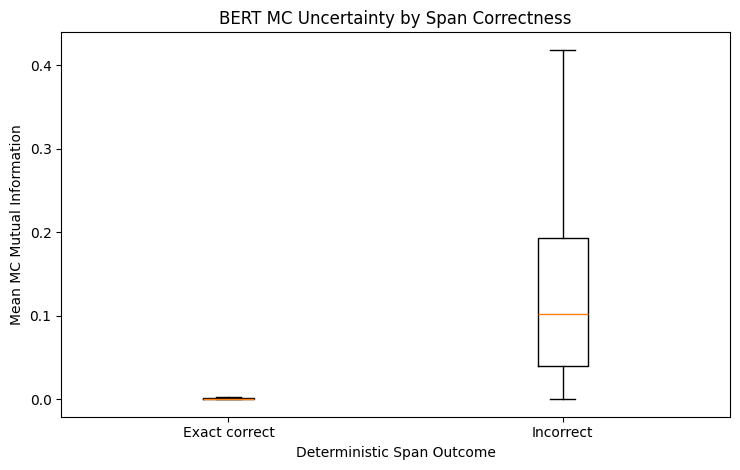

Figure saved to:
/kaggle/working/01_bert_baseline_and_uncertainty/figures/validation_mc_span_mi_by_correctness.png


In [90]:
correct_span_mi = (
    validation_prediction_uncertainty_df.loc[
        ~validation_prediction_uncertainty_df[
            "is_prediction_error"
        ],
        "mc_span_mean_mutual_information",
    ]
    .to_numpy(
        dtype=float
    )
)


incorrect_span_mi = (
    validation_prediction_uncertainty_df.loc[
        validation_prediction_uncertainty_df[
            "is_prediction_error"
        ],
        "mc_span_mean_mutual_information",
    ]
    .to_numpy(
        dtype=float
    )
)


plt.figure(
    figsize=(7.5, 4.8)
)


plt.boxplot(
    [
        correct_span_mi,
        incorrect_span_mi,
    ],

    tick_labels=[
        "Exact correct",
        "Incorrect",
    ],

    showfliers=False,
)


plt.xlabel(
    "Deterministic Span Outcome"
)

plt.ylabel(
    "Mean MC Mutual Information"
)

plt.title(
    "BERT MC Uncertainty by Span Correctness"
)


plt.tight_layout()


whole_span_mi_figure_path = (
    FIGURE_OUTPUT_DIR
    / (
        "validation_mc_span_mi_"
        "by_correctness.png"
    )
)


plt.savefig(
    whole_span_mi_figure_path,
    dpi=300,
    bbox_inches="tight",
)


plt.show()


print(
    "Figure saved to:"
)

print(
    whole_span_mi_figure_path
)

### 17.6 Save the BERT Uncertainty Protocol

The uncertainty protocol records the exact model identity, stochastic-inference settings and interpretation of the BERT-specific boundary signals.

This file allows downstream notebooks to verify that they are consuming features generated from the intended frozen BERT model and uncertainty procedure.

In [91]:
uncertainty_protocol = {
    "model": (
        MODEL_CHECKPOINT
    ),

    "model_sha256": (
        reloaded_model_hash
    ),

    "max_length": (
        MAX_LENGTH
    ),

    "mc_dropout": {
        "passes": (
            MC_DROPOUT_PASSES
        ),

        "pass_seeds": (
            MC_PASS_SEEDS
        ),

        "parameters_frozen": True,

        "only_dropout_modules_activated": True,

        "mean_distribution_used_to_redefine_predictions": (
            False
        ),

        "interpretation": (
            "Stochastic model-disagreement "
            "and uncertainty proxy; not assumed "
            "to be a calibrated probability of "
            "epistemic error."
        ),
    },

    "deterministic_span_confidence": {
        "construction": (
            "Geometric mean of token probabilities "
            "assigned to the emitted BIO labels."
        ),

        "status": (
            "Project-specific deterministic "
            "span-confidence construction."
        ),
    },

    "bert_boundary_signals": {
        "start": (
            "P(I-X at s) / "
            "[P(B-X at s) + P(I-X at s) + epsilon]"
        ),

        "end": (
            "P(I-X at e+1), or 0 when the "
            "predicted entity ends at the final "
            "original token."
        ),

        "joint": (
            "max(start_signal, end_signal)"
        ),

        "interpretation": (
            "Architecture-specific BIO boundary "
            "signals; not calibrated boundary-error "
            "probabilities."
        ),

        "start_end_are_symmetric": (
            False
        ),
    },

    "mc_statistics": [
        "predictive_entropy",
        "expected_entropy",
        "mutual_information",
        "class_probability_variance",
        "fixed_label_vote_fraction",
        "variation_ratio",
    ],

    "data_use": {
        "validation_interpreted": True,

        "probability_calibration_features_generated": (
            True
        ),

        "probability_calibration_used_for_model_selection": (
            False
        ),

        "conformal_calibration_features_generated": (
            True
        ),

        "conformal_calibration_used_for_model_selection": (
            False
        ),

        "probability_calibration_fitted_here": (
            False
        ),

        "conformal_prediction_fitted_here": (
            False
        ),

        "test_accessed": (
            False
        ),
    },
}


uncertainty_protocol_path = (
    CONFIG_OUTPUT_DIR
    / "bert_uncertainty_protocol.json"
)


with open(
    uncertainty_protocol_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        uncertainty_protocol,
        file,
        indent=2,
    )


print(
    "BERT uncertainty protocol saved to:"
)

print(
    uncertainty_protocol_path
)

BERT uncertainty protocol saved to:
/kaggle/working/01_bert_baseline_and_uncertainty/configuration/bert_uncertainty_protocol.json


### 17.7 Save the Final Output Manifest

The manifest records the reusable outputs produced by this merged BERT baseline-and-uncertainty notebook.

Downstream notebooks should consume these saved artefacts rather than retraining BERT or rerunning Monte Carlo Dropout unless the frozen model or uncertainty protocol is intentionally changed.

In [92]:
output_manifest_df = pd.DataFrame([
    {
        "Artifact": (
            "Fine-tuned BERT checkpoint"
        ),

        "Location": str(
            MODEL_DIR
        ),

        "Purpose": (
            "Verified frozen BERT model"
        ),
    },

    {
        "Artifact": (
            "Checkpoint-integrity record"
        ),

        "Location": str(
            checkpoint_integrity_path
        ),

        "Purpose": (
            "Model hash, loading audit and "
            "prediction-reproduction check"
        ),
    },

    {
        "Artifact": (
            "Deterministic prediction arrays"
        ),

        "Location": str(
            PREDICTION_ARRAY_DIR
        ),

        "Purpose": (
            "Raw logits, probabilities and "
            "BIO predictions"
        ),
    },

    {
        "Artifact": (
            "Original-word prediction tables"
        ),

        "Location": str(
            TOKEN_OUTPUT_DIR
        ),

        "Purpose": (
            "Deterministic original-token "
            "predictions and probabilities"
        ),
    },

    {
        "Artifact": (
            "Deterministic span tables"
        ),

        "Location": str(
            SPAN_OUTPUT_DIR
        ),

        "Purpose": (
            "Gold and emitted BERT spans"
        ),
    },

    {
        "Artifact": (
            "Span-matching tables"
        ),

        "Location": str(
            MATCHING_OUTPUT_DIR
        ),

        "Purpose": (
            "Strict and diagnostic "
            "correctness events"
        ),
    },

    {
        "Artifact": (
            "MC-Dropout arrays"
        ),

        "Location": str(
            MC_ARRAY_OUTPUT_DIR
        ),

        "Purpose": (
            "Compact stochastic token "
            "statistics"
        ),
    },

    {
        "Artifact": (
            "Original-token MC uncertainty"
        ),

        "Location": str(
            TOKEN_UNCERTAINTY_DIR
        ),

        "Purpose": (
            "Fixed token predictions with "
            "MC-Dropout statistics"
        ),
    },

    {
        "Artifact": (
            "Fixed-span uncertainty tables"
        ),

        "Location": str(
            SPAN_UNCERTAINTY_DIR
        ),

        "Purpose": (
            "Deterministic BERT spans with "
            "deterministic and MC uncertainty"
        ),
    },

    {
        "Artifact": (
            "BERT uncertainty protocol"
        ),

        "Location": str(
            uncertainty_protocol_path
        ),

        "Purpose": (
            "Frozen uncertainty definitions "
            "and data-use rules"
        ),
    },
])


output_manifest_path = (
    OUTPUT_DIR
    / "output_manifest.csv"
)


output_manifest_df.to_csv(
    output_manifest_path,
    index=False,
)


print(
    "Final BERT output manifest:"
)

display(
    output_manifest_df
)

Final BERT output manifest:


,Artifact,Location,Purpose
0,Fine-tuned BERT checkpoint,/kaggle/working/01_bert_baseline_and_uncertain...,Verified frozen BERT model
1,Checkpoint-integrity record,/kaggle/working/01_bert_baseline_and_uncertain...,"Model hash, loading audit and prediction-repro..."
2,Deterministic prediction arrays,/kaggle/working/01_bert_baseline_and_uncertain...,"Raw logits, probabilities and BIO predictions"
3,Original-word prediction tables,/kaggle/working/01_bert_baseline_and_uncertain...,Deterministic original-token predictions and p...
4,Deterministic span tables,/kaggle/working/01_bert_baseline_and_uncertain...,Gold and emitted BERT spans
5,Span-matching tables,/kaggle/working/01_bert_baseline_and_uncertain...,Strict and diagnostic correctness events
6,MC-Dropout arrays,/kaggle/working/01_bert_baseline_and_uncertain...,Compact stochastic token statistics
7,Original-token MC uncertainty,/kaggle/working/01_bert_baseline_and_uncertain...,Fixed token predictions with MC-Dropout statis...
8,Fixed-span uncertainty tables,/kaggle/working/01_bert_baseline_and_uncertain...,Deterministic BERT spans with deterministic an...
9,BERT uncertainty protocol,/kaggle/working/01_bert_baseline_and_uncertain...,Frozen uncertainty definitions and data-use rules


In [93]:
completion_record = {
    "notebook": (
        "01_BERT_Baseline_and_Uncertainty"
    ),

    "status": (
        "complete"
    ),

    "model_checkpoint": (
        MODEL_CHECKPOINT
    ),

    "model_sha256": (
        reloaded_model_hash
    ),

    "validation_predictions": int(
        validation_prediction_count
    ),

    "validation_strict_precision": float(
        strict_precision
    ),

    "validation_strict_recall": float(
        strict_recall
    ),

    "validation_strict_f1": float(
        strict_f1
    ),

    "validation_start_boundary_errors": int(
        start_error_count
    ),

    "validation_end_boundary_errors": int(
        end_error_count
    ),

    "validation_any_boundary_errors": int(
        any_boundary_error_count
    ),

    "validation_both_boundary_errors": int(
        both_boundary_error_count
    ),

    "mc_dropout_passes": int(
        MC_DROPOUT_PASSES
    ),

    "mc_pass_seeds": (
        MC_PASS_SEEDS
    ),

    "deterministic_prediction_population_preserved": (
        True
    ),

    "model_parameters_frozen_during_uncertainty": (
        True
    ),

    "probability_calibration_features_generated": (
        True
    ),

    "conformal_calibration_features_generated": (
        True
    ),

    "probability_calibration_fitted": (
        False
    ),

    "conformal_prediction_fitted": (
        False
    ),

    "test_accessed": (
        False
    ),

    "next_notebook": (
        "02_SpanNER_Baseline_and_Uncertainty"
    ),
}


completion_record_path = (
    CONFIG_OUTPUT_DIR
    / "bert_notebook_completion.json"
)


with open(
    completion_record_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        completion_record,
        file,
        indent=2,
    )


print(
    "Completion record saved to:"
)

print(
    completion_record_path
)

Completion record saved to:
/kaggle/working/01_bert_baseline_and_uncertainty/configuration/bert_notebook_completion.json


### 17.9 Final Integrity Lock

Before the notebook is considered complete, the final state must satisfy all experimental constraints established above.

In [94]:
final_integrity_checks = {
    "Notebook 00 identities verified": (
        identity_verification_df[
            "Identity Match"
        ].all()
    ),

    "Checkpoint loading clean": (
        len(
            missing_keys
        ) == 0
        and len(
            unexpected_keys
        ) == 0
        and len(
            mismatched_keys
        ) == 0
    ),

    "Saved/reloaded parameters identical": (
        all_parameters_identical
    ),

    "Checkpoint predictions reproduced": (
        predictions_identical
        and logits_numerically_equivalent
    ),

    "BERT parameters frozen": (
        sum(
            parameter.numel()
            for parameter
            in model.parameters()
            if parameter.requires_grad
        )
        == 0
    ),

    "Model returned to evaluation mode": (
        model.training
        is False
    ),

    "Validation fixed-span population preserved": (
        len(
            span_uncertainty_tables[
                "validation"
            ]
        )
        == len(
            predicted_span_tables[
                "validation"
            ]
        )
    ),

    "Probability-calibration span population preserved": (
        len(
            span_uncertainty_tables[
                "probability_calibration"
            ]
        )
        == len(
            predicted_span_tables[
                "probability_calibration"
            ]
        )
    ),

    "Conformal-calibration span population preserved": (
        len(
            span_uncertainty_tables[
                "conformal_calibration"
            ]
        )
        == len(
            predicted_span_tables[
                "conformal_calibration"
            ]
        )
    ),

    "Validation strict F1 reproduced": (
        absolute_f1_difference
        <= 1e-6
    ),

    "Validation event counts internally consistent": (
        exact_correct_count
        == true_positives
        and prediction_error_count
        == false_positives
        and start_error_count
        == start_boundary_errors
        and end_error_count
        == end_boundary_errors
    ),

    "All MC passes distinct": all(
        len(
            set(
                mc_results[
                    split_name
                ][
                    "pass_probability_hashes"
                ]
            )
        )
        == MC_DROPOUT_PASSES
        for split_name
        in prediction_splits
    ),

    "Official test absent": (
        RUN_FINAL_TEST
        is False
        and "test"
        not in dataset
    ),

    "Uncertainty protocol saved": (
        uncertainty_protocol_path.exists()
    ),

    "Completion record saved": (
        completion_record_path.exists()
    ),
}


final_integrity_df = pd.DataFrame({
    "Check": list(
        final_integrity_checks.keys()
    ),

    "Passed": list(
        final_integrity_checks.values()
    ),
})


print(
    "Final BERT notebook integrity checks:"
)

display(
    final_integrity_df
)


assert (
    final_integrity_df[
        "Passed"
    ].all()
)


print(
    "\nAll final integrity checks passed."
)

Final BERT notebook integrity checks:


,Check,Passed
0,Notebook 00 identities verified,True
1,Checkpoint loading clean,True
2,Saved/reloaded parameters identical,True
3,Checkpoint predictions reproduced,True
4,BERT parameters frozen,True
5,Model returned to evaluation mode,True
6,Validation fixed-span population preserved,True
7,Probability-calibration span population preserved,True
8,Conformal-calibration span population preserved,True
9,Validation strict F1 reproduced,True



All final integrity checks passed.


## Notebook Summary

This notebook establishes the complete BERT baseline and uncertainty representation used in the dissertation.

The completed pipeline:

- reconstructs the fixed development populations from the Notebook 00 registry without creating any new data split;
- fine-tunes `bert-base-cased` for BIO token classification using training data only, with validation F1 used for checkpoint selection;
- saves and independently reloads the selected checkpoint;
- verifies clean parameter loading, exact trained-weight equality and deterministic prediction reproduction;
- freezes the verified BERT model before all uncertainty analysis;
- generates deterministic token probabilities and reconstructs original-word BIO predictions;
- converts BIO sequences into typed entity spans and evaluates strict validation NER performance;
- creates one-to-one diagnostic span matching and separate start- and end-boundary correctness events;
- uses a project-specific geometric aggregation of emitted-token probabilities as deterministic BERT span confidence;
- derives architecture-specific BIO start-boundary and end-continuation signals while retaining their asymmetric definitions;
- performs ten seeded Monte Carlo Dropout passes with all learned parameters frozen and only dropout modules activated;
- extracts predictive entropy, expected entropy, mutual information, probability variance and vote-instability statistics;
- aggregates stochastic quantities onto the same fixed deterministic BERT spans rather than redefining predictions from the MC-mean distribution;
- generates uncertainty features for validation, probability calibration and conformal calibration without fitting calibration or conformal procedures;
- constructs a validation prediction-side table linking uncertainty features to exact and boundary-specific correctness events;
- performs validation-only descriptive sanity checks without selecting an uncertainty method;
- does not access or evaluate the official CoNLL-2003 test split.

The saved BERT outputs now form the frozen input to the later architecture-comparison, probability-calibration and conformal-prediction stages.

The next notebook constructs the corresponding **SpanNER baseline and uncertainty representation**.